In [125]:
import rasterio
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:
DIR_FILE = "merit_colorado_dir_native.tif"
FLOAT_FILE = "merit_colorado_float_native.tif"


with rasterio.open(DIR_FILE) as src:
    print("DIR")
    print("Shape:", src.shape)
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("Transform:", src.transform)
    print("Bounds:", src.bounds)
    dir_transform = src.transform
    dir_shape = src.shape


with rasterio.open(FLOAT_FILE) as src:
    print("\nFLOAT")
    print("Shape:", src.shape)
    print("Bands:", src.count)
    print("Dtypes:", src.dtypes)
    print("Transform:", src.transform)
    print("Bounds:", src.bounds)
    float_transform = src.transform
    float_shape = src.shape


print("\nSame shape:", dir_shape == float_shape)
print("Same transform:", dir_transform == float_transform)

DIR
Shape: (15806, 15001)
Bands: 1
Dtype: ('uint8',)
Transform: | 0.00, 0.00,-117.50|
| 0.00,-0.00, 44.17|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-117.50041666666667, bottom=30.999583333333334, right=-104.99958333333333, top=44.17125)

FLOAT
Shape: (15806, 15001)
Bands: 4
Dtypes: ('float32', 'float32', 'float32', 'float32')
Transform: | 0.00, 0.00,-117.50|
| 0.00,-0.00, 44.17|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-117.50041666666667, bottom=30.999583333333334, right=-104.99958333333333, top=44.17125)

Same shape: True
Same transform: True


In [3]:
with rasterio.open(DIR_FILE) as src:
    direction_sample = src.read(
        1,
        out_shape=(500, 500)
    )

with rasterio.open(FLOAT_FILE) as src:
    upa_sample = src.read(
        1,
        out_shape=(500, 500)
    )

print("\nDirection values:")
print(np.unique(direction_sample))

print("\nUPA sample min:", np.nanmin(upa_sample))
print("UPA sample max:", np.nanmax(upa_sample))


Direction values:
[  0   1   2   4   8  16  32  64 128]

UPA sample min: 0.0061785844
UPA sample max: 618588.5


In [4]:
with rasterio.open(DIR_FILE) as src:
    print("Resolution:", src.res)

    print("Pixel width:", src.transform.a)
    print("Pixel height:", src.transform.e)

Resolution: (0.0008333333333333334, 0.0008333333333333334)
Pixel width: 0.0008333333333333334
Pixel height: -0.0008333333333333334


In [5]:
DIR_FILE = "merit_colorado_dir_native.tif"
FLOAT_FILE = "merit_colorado_float_native.tif"

# Minimum upstream drainage area in km^2
UPA_THRESHOLD = 10000

In [6]:
with rasterio.open(DIR_FILE) as src:
    direction = src.read(1)

    transform = src.transform
    rows = src.height
    cols = src.width

with rasterio.open(FLOAT_FILE) as src:
    # Band 1 = upa
    upa = src.read(1)

print("Direction shape:", direction.shape)
print("UPA shape:", upa.shape)
print("Maximum UPA:", np.nanmax(upa))
print("Resolution:", abs(transform.a))

Direction shape: (15806, 15001)
UPA shape: (15806, 15001)
Maximum UPA: 622761.06
Resolution: 0.0008333333333333334


In [7]:
river_mask = upa >= UPA_THRESHOLD

river_rows, river_cols = np.where(river_mask)

print(
    f"River pixels with UPA >= {UPA_THRESHOLD:,} km²:",
    len(river_rows)
)

River pixels with UPA >= 10,000 km²: 124374


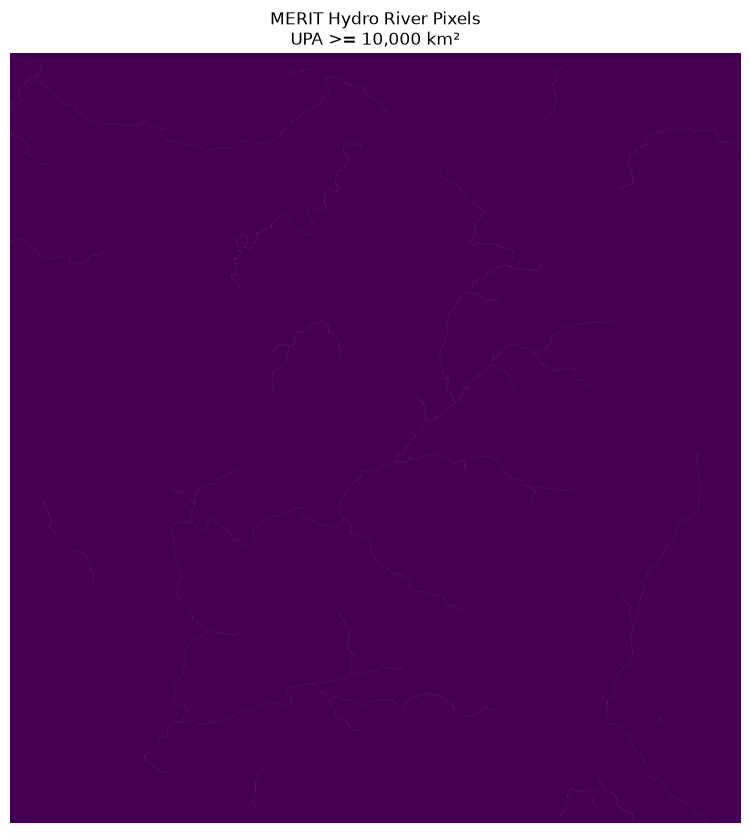

In [8]:
plt.figure(figsize=(12, 10))

plt.imshow(river_mask)

plt.title(
    f"MERIT Hydro River Pixels\n"
    f"UPA >= {UPA_THRESHOLD:,} km²"
)

plt.axis("off")
plt.show()

In [9]:
flow_offsets = {
    1:   (0, 1),      # East
    2:   (1, 1),      # Southeast
    4:   (1, 0),      # South
    8:   (1, -1),     # Southwest
    16:  (0, -1),     # West
    32:  (-1, -1),    # Northwest
    64:  (-1, 0),     # North
    128: (-1, 1)      # Northeast
}

In [10]:
G = nx.DiGraph()

In [11]:
node_ids = (
    river_rows.astype(np.int64) * cols
    + river_cols
)

G.add_nodes_from(node_ids.tolist())

print("Nodes added:", G.number_of_nodes())

Nodes added: 124374


In [12]:
for r, c in zip(river_rows, river_cols):

    d = int(direction[r, c])

    # Ignore cells without a valid downstream direction
    if d not in flow_offsets:
        continue

    dr, dc = flow_offsets[d]

    downstream_row = r + dr
    downstream_col = c + dc

    # Make sure downstream location is inside the raster
    if not (
        0 <= downstream_row < rows
        and 0 <= downstream_col < cols
    ):
        continue

    # Only connect to another pixel above our UPA threshold
    if not river_mask[downstream_row, downstream_col]:
        continue

    node1 = int(r * cols + c)

    node2 = int(
        downstream_row * cols
        + downstream_col
    )

    G.add_edge(node1, node2)

In [13]:
print("Finished building graph.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Finished building graph.
Nodes: 124374
Edges: 124353


In [14]:
components = list(
    nx.weakly_connected_components(G)
)

component_sizes = sorted(
    [len(component) for component in components],
    reverse=True
)

print("----- GRAPH RESULTS -----")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Weakly connected components:", len(components))

print()
print("Largest 10 component sizes:")
print(component_sizes[:10])

----- GRAPH RESULTS -----
Nodes: 124374
Edges: 124353
Weakly connected components: 21

Largest 10 component sizes:
[67401, 12084, 11050, 9587, 4757, 4547, 2741, 2613, 2116, 1874]


In [15]:
largest_nodes = max(
    components,
    key=len
)

largest = G.subgraph(
    largest_nodes
).copy()

print("----- LARGEST COMPONENT -----")
print("Nodes:", largest.number_of_nodes())
print("Edges:", largest.number_of_edges())

----- LARGEST COMPONENT -----
Nodes: 67401
Edges: 67400


In [16]:
def graph_to_segments(graph):

    segments = []

    for u, v in graph.edges():

        # Convert node ID back to row and column
        r1 = u // cols
        c1 = u % cols

        r2 = v // cols
        c2 = v % cols

        # Convert raster cells into longitude/latitude
        lon1, lat1 = rasterio.transform.xy(
            transform,
            r1,
            c1,
            offset="center"
        )

        lon2, lat2 = rasterio.transform.xy(
            transform,
            r2,
            c2,
            offset="center"
        )

        segments.append([
            (lon1, lat1),
            (lon2, lat2)
        ])

    return segments

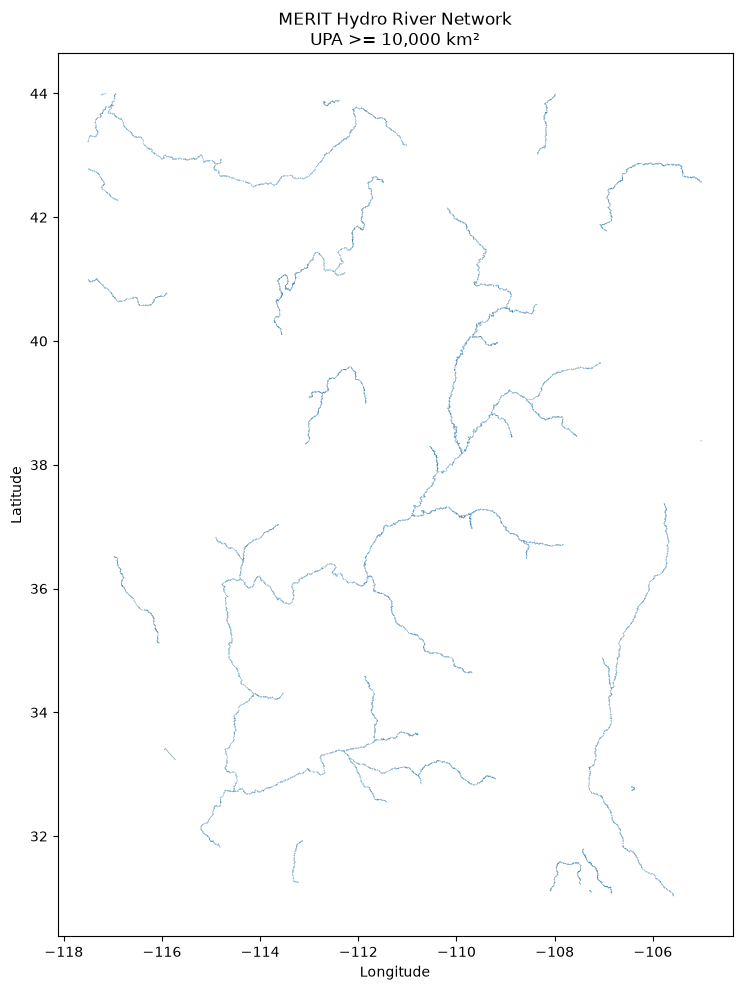

In [17]:
segments = graph_to_segments(G)

fig, ax = plt.subplots(figsize=(12, 10))

lines = LineCollection(
    segments,
    linewidths=0.35
)

ax.add_collection(lines)
ax.autoscale()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    f"MERIT Hydro River Network\n"
    f"UPA >= {UPA_THRESHOLD:,} km²"
)

# Correct approximately for longitude/latitude distortion
mean_latitude = (
    ax.get_ylim()[0]
    + ax.get_ylim()[1]
) / 2

ax.set_aspect(
    1 / np.cos(np.deg2rad(mean_latitude))
)

plt.tight_layout()
plt.show()

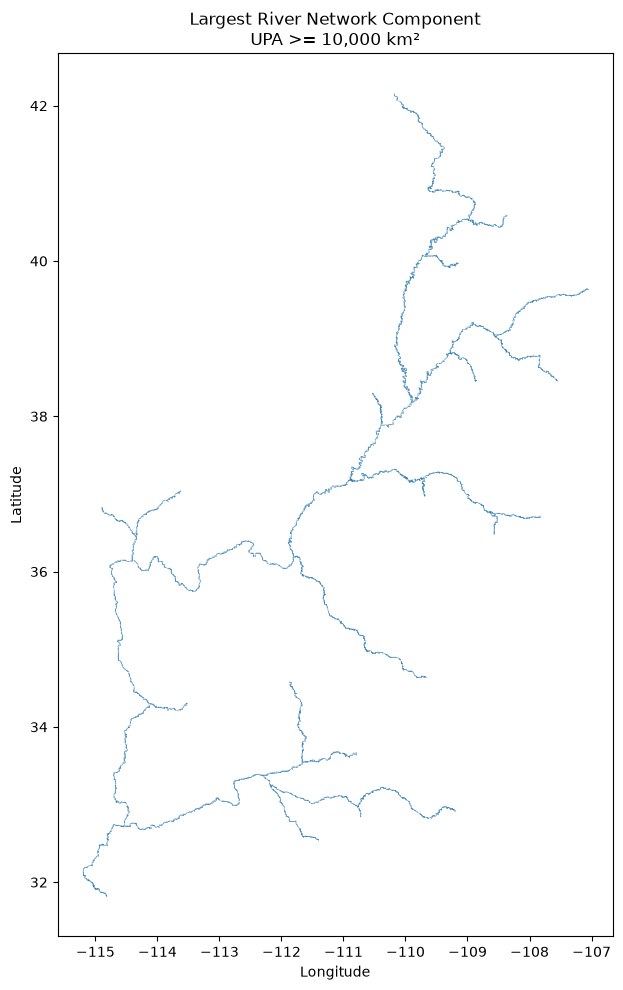

In [18]:
largest_segments = graph_to_segments(largest)

fig, ax = plt.subplots(figsize=(10, 10))

lines = LineCollection(
    largest_segments,
    linewidths=0.6
)

ax.add_collection(lines)
ax.autoscale()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    f"Largest River Network Component\n"
    f"UPA >= {UPA_THRESHOLD:,} km²"
)

mean_latitude = (
    ax.get_ylim()[0]
    + ax.get_ylim()[1]
) / 2

ax.set_aspect(
    1 / np.cos(np.deg2rad(mean_latitude))
)

plt.tight_layout()
plt.show()

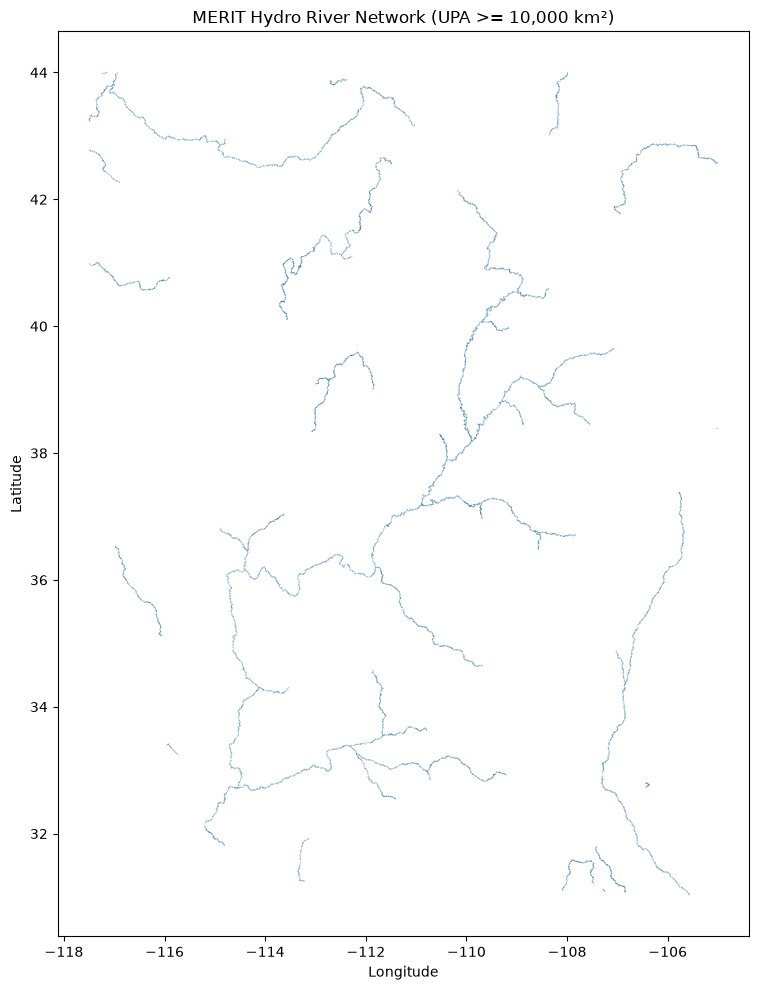

In [19]:
segments = graph_to_segments(G)

fig, ax = plt.subplots(figsize=(12, 10))

ax.add_collection(
    LineCollection(
        segments,
        linewidths=0.35
    )
)

ax.autoscale()

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    f"MERIT Hydro River Network "
    f"(UPA >= {UPA_THRESHOLD:,} km²)"
)

mean_latitude = (
    ax.get_ylim()[0]
    + ax.get_ylim()[1]
) / 2

ax.set_aspect(
    1 / np.cos(np.deg2rad(mean_latitude))
)

plt.tight_layout()

plt.savefig(
    "river_network_full.png",
    dpi=300
)

plt.show()

In [20]:
direction.shape

(15806, 15001)

In [21]:
nx.write_graphml(
    largest,
    "largest_river_network.graphml"
)

print("Graph saved.")

Graph saved.


# Load the graph without the .tif

In [14]:
largest = nx.read_graphml(
    "largest_river_network.graphml"
)

print("Nodes:", largest.number_of_nodes())
print("Edges:", largest.number_of_edges())
print("Directed:", largest.is_directed())

Nodes: 67401
Edges: 67400
Directed: True


In [15]:
from collections import Counter

degree_counts = Counter(
    degree for node, degree in largest.degree()
)

max_degree = max(degree_counts)

for n in range(1, max_degree + 1):
    print(
        f"Degree {n}:",
        degree_counts.get(n, 0),
        "nodes"
    )

Degree 1: 20 nodes
Degree 2: 67363 nodes
Degree 3: 18 nodes


In [16]:
# Keep node ordering so matrix rows/columns correspond to nodes
nodes = list(largest.nodes())

# Sparse adjacency matrix
A = nx.to_scipy_sparse_array(
    largest,
    nodelist=nodes,
    dtype=np.int8
)

# Row sums = number of outgoing edges
out_degrees = np.asarray(A.sum(axis=1)).flatten()

# Column sums = number of incoming edges
in_degrees = np.asarray(A.sum(axis=0)).flatten()


# Find nodes that split into multiple directions
# but are NOT meeting/confluence points
split_nodes = []

for i, node in enumerate(nodes):

    if out_degrees[i] > 1 and in_degrees[i] <= 1:

        split_nodes.append({
            "node": node,
            "in_degree": int(in_degrees[i]),
            "out_degree": int(out_degrees[i])
        })


print("Non-meeting nodes with multiple outgoing edges:")
print("Count:", len(split_nodes))

for item in split_nodes[:20]:
    print(item)

NameError: name 'np' is not defined

In [ ]:
G_stations = G.copy()

print("Original graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print()

print("Copy:")
print("Nodes:", G_stations.number_of_nodes())
print("Edges:", G_stations.number_of_edges())

Original graph:
Nodes: 124374
Edges: 124353

Copy:
Nodes: 124374
Edges: 124353


In [ ]:
import rasterio
from rasterio.transform import xy

DIR_FILE = "merit_colorado_dir_native.tif"

with rasterio.open(DIR_FILE) as src:
    river_transform = src.transform
    river_crs = src.crs
    cols = src.width

print("Raster CRS:", river_crs)
print("Number of columns:", cols)


def get_lon_lat(G, node):
    node_id = int(node)

    row = node_id // cols
    col = node_id % cols

    lon, lat = xy(
        river_transform,
        row,
        col,
        offset="center"
    )

    return float(lon), float(lat)

Raster CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Number of columns: 15001


ERROR 1: PROJ: internal_proj_identify: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [ ]:
test_node = next(iter(G_stations.nodes()))

print("Node:", test_node)
print("Coordinates:", get_lon_lat(G_stations, test_node))

Node: 3075612
Coordinates: (-117.16083333333333, 44.0)


In [ ]:
for node in G_stations.nodes():

    lon, lat = get_lon_lat(G_stations, node)

    G_stations.nodes[node]["longitude"] = float(lon)
    G_stations.nodes[node]["latitude"] = float(lat)

In [ ]:
for node in G_stations.nodes():

    node_id = int(node)

    row = node_id // cols
    col = node_id % cols

    lon, lat = get_lon_lat(G_stations, node)

    G_stations.nodes[node]["row"] = int(row)
    G_stations.nodes[node]["col"] = int(col)
    G_stations.nodes[node]["longitude"] = float(lon)
    G_stations.nodes[node]["latitude"] = float(lat)

print("Coordinates added to all nodes.")

Coordinates added to all nodes.


In [ ]:
node = next(iter(G_stations.nodes()))

print("Node ID:", node)
print("Attributes:", G_stations.nodes[node])

Node ID: 3075612
Attributes: {'longitude': -117.16083333333333, 'latitude': 44.0, 'row': 205, 'col': 407}


In [ ]:
import requests
import pandas as pd
import numpy as np
import io
import time

In [ ]:
lons = [
    data["longitude"]
    for node, data in G_stations.nodes(data=True)
]

lats = [
    data["latitude"]
    for node, data in G_stations.nodes(data=True)
]

west = min(lons)
east = max(lons)
south = min(lats)
north = max(lats)

print("Graph bounding box:")
print("West: ", west)
print("East: ", east)
print("South:", south)
print("North:", north)

Graph bounding box:
West:  -117.5
East:  -105.0
South: 31.026666666666664
North: 44.0


In [ ]:
WQP_URL = "https://www.waterqualitydata.us/wqx3/Station/search"


def download_station_tile(west, south, east, north):

    params = [
        ("bBox", f"{west},{south},{east},{north}"),
        ("mimeType", "csv"),

        ("providers", "NWIS"),
        ("providers", "STORET"),
        ("providers", "STEWARDS"),
        ("providers", "BIODATA"),
    ]

    try:
        response = requests.get(
            WQP_URL,
            params=params,
            timeout=180
        )

        response.raise_for_status()

        # No data returned
        if len(response.content) == 0:
            return pd.DataFrame()

        df = pd.read_csv(
            io.BytesIO(response.content),
            low_memory=False
        )

        return df

    except Exception as e:
        print("ERROR:", e)
        return pd.DataFrame()

In [ ]:
TILE_SIZE = 1.0

tiles = []

x = west

while x < east:

    y = south

    while y < north:

        tile_west = x
        tile_east = min(x + TILE_SIZE, east)

        tile_south = y
        tile_north = min(y + TILE_SIZE, north)

        tiles.append(
            (
                tile_west,
                tile_south,
                tile_east,
                tile_north
            )
        )

        y += TILE_SIZE

    x += TILE_SIZE


print("Number of API tiles:", len(tiles))

Number of API tiles: 169


In [ ]:
station_dataframes = []

for i, tile in enumerate(tiles, start=1):

    w, s, e, n = tile

    print(
        f"Downloading tile {i}/{len(tiles)} "
        f"({w:.2f}, {s:.2f}, {e:.2f}, {n:.2f})"
    )

    df = download_station_tile(
        w,
        s,
        e,
        n
    )

    print("   Stations returned:", len(df))

    if not df.empty:
        station_dataframes.append(df)

    # Be polite to the server
    time.sleep(0.5)

   Stations returned: 52
   Stations returned: 4737
   Stations returned: 9644
   Stations returned: 9150
   Stations returned: 820
   Stations returned: 893
   Stations returned: 335
   Stations returned: 348
   Stations returned: 476
   Stations returned: 603
   Stations returned: 236
   Stations returned: 292
   Stations returned: 4325
   Stations returned: 5
   Stations returned: 841
   Stations returned: 1421
   Stations returned: 1230
   Stations returned: 603
   Stations returned: 2088
   Stations returned: 4556
   Stations returned: 492
   Stations returned: 657
   Stations returned: 664
   Stations returned: 527
   Stations returned: 835
   Stations returned: 6464
   Stations returned: 10
   Stations returned: 8428
   Stations returned: 5346
   Stations returned: 3310
   Stations returned: 2442
   Stations returned: 2175
   Stations returned: 218
   Stations returned: 476
   Stations returned: 552
   Stations returned: 405
   Stations returned: 382
   Stations returned: 3540
 

In [ ]:
if len(station_dataframes) == 0:
    raise RuntimeError(
        "No stations were downloaded."
    )

stations = pd.concat(
    station_dataframes,
    ignore_index=True
)

print("Total rows downloaded:", len(stations))

Total rows downloaded: 348872


In [ ]:
if "MonitoringLocationIdentifier" in stations.columns:

    stations = stations.drop_duplicates(
        subset="MonitoringLocationIdentifier"
    )

else:
    stations = stations.drop_duplicates()


stations = stations.reset_index(drop=True)

print("Unique monitoring stations:", len(stations))

Unique monitoring stations: 348854


In [ ]:
print(stations.columns.tolist())
columns_to_show = [
    "MonitoringLocationIdentifier",
    "MonitoringLocationName",
    "MonitoringLocationTypeName",
    "OrganizationFormalName",
    "LatitudeMeasure",
    "LongitudeMeasure",
    "ProviderName"
]

columns_to_show = [
    col
    for col in columns_to_show
    if col in stations.columns
]

stations[columns_to_show].head(20)

['Org_Identifier', 'Org_FormalName', 'ProviderName', 'Location_Identifier', 'Location_Name', 'Location_Type', 'Location_Description', 'Location_State', 'Location_CountryName', 'Location_CountyName', 'Location_CountryCode', 'Location_StatePostalCode', 'Location_CountyCode', 'Location_HUCEightDigitCode', 'Location_HUCTwelveDigitCode', 'Location_TribalLandIndicator', 'Location_TribalLand', 'Location_Latitude', 'Location_Longitude', 'Location_HorzCoordReferenceSystemDatum', 'Location_LatitudeStandardized', 'Location_LongitudeStandardized', 'Location_HorzCoordStandardizedDatum', 'Location_SourceMapScale', 'Location_HorzAccuracyMeasure', 'Location_HorzAccuracyMeasureUnit', 'Location_HorzCollectionMethod', 'Location_VerticalMeasure', 'Location_VerticalMeasureUnit', 'Location_VerticalAccuracyMeasure', 'Location_VerticalAccuracyMeasureUnit', 'Location_VertCollectionMethod', 'Location_VertCoordReferenceSystemDatum', 'Location_WellType', 'Location_AquiferType', 'Location_NationalAquifer', 'Locati

,ProviderName
0,STORET
1,STORET
2,STORET
3,STORET
4,STORET
5,STORET
6,STORET
7,STORET
8,STORET
9,STORET


In [ ]:
# Rename WQX3 column names to the names used in the rest of our notebook

stations = stations.rename(columns={
    "Org_Identifier": "OrganizationIdentifier",
    "Org_FormalName": "OrganizationFormalName",

    "Location_Identifier": "MonitoringLocationIdentifier",
    "Location_Name": "MonitoringLocationName",
    "Location_Type": "MonitoringLocationTypeName",

    "Location_Latitude": "LatitudeMeasure",
    "Location_Longitude": "LongitudeMeasure"
})

print("Columns renamed.")

Columns renamed.


In [ ]:
# Prefer standardized coordinates when available

standard_lat = pd.to_numeric(
    stations["Location_LatitudeStandardized"],
    errors="coerce"
)

standard_lon = pd.to_numeric(
    stations["Location_LongitudeStandardized"],
    errors="coerce"
)

raw_lat = pd.to_numeric(
    stations["LatitudeMeasure"],
    errors="coerce"
)

raw_lon = pd.to_numeric(
    stations["LongitudeMeasure"],
    errors="coerce"
)

# Use standardized value first, raw value as fallback
stations["LatitudeMeasure"] = standard_lat.fillna(raw_lat)
stations["LongitudeMeasure"] = standard_lon.fillna(raw_lon)

In [ ]:
required = [
    "MonitoringLocationIdentifier",
    "MonitoringLocationName",
    "MonitoringLocationTypeName",
    "LatitudeMeasure",
    "LongitudeMeasure",
    "OrganizationFormalName",
    "ProviderName"
]

for col in required:
    print(col, "->", col in stations.columns)

MonitoringLocationIdentifier -> True
MonitoringLocationName -> True
MonitoringLocationTypeName -> True
LatitudeMeasure -> True
LongitudeMeasure -> True
OrganizationFormalName -> True
ProviderName -> True


In [ ]:
stations[
    "MonitoringLocationTypeName"
].value_counts().head(30)

MonitoringLocationTypeName
Well                                 174485
River/Stream                          36899
Stream                                17005
Spring                                15385
Other-Surface Water                    5934
Lake                                   5158
Test hole not completed as a well      5150
Atmosphere                             3896
Reservoir                              2878
CERCLA Superfund Site                  2198
Lake, Reservoir, Impoundment           2014
Soil hole                              1384
Land                                   1376
Tunnel, shaft, or mine                  977
Ocean                                   862
Canal                                   856
Ditch                                   779
Estuary                                 740
Facility Other                          547
Diversion                               540
Groundwater drain                       486
River/Stream Perennial                  482
Facil

In [ ]:
stations = stations.dropna(
    subset=[
        "LatitudeMeasure",
        "LongitudeMeasure"
    ]
).copy()

stations = stations[
    stations["LatitudeMeasure"].between(-90, 90)
    &
    stations["LongitudeMeasure"].between(-180, 180)
].copy()

print("Stations with usable coordinates:", len(stations))

Stations with usable coordinates: 284957


In [ ]:
before = len(stations)

stations = stations.drop_duplicates(
    subset="MonitoringLocationIdentifier"
).reset_index(drop=True)

after = len(stations)

print("Before duplicate removal:", before)
print("After duplicate removal:", after)
print("Duplicates removed:", before - after)

Before duplicate removal: 284957
After duplicate removal: 284956
Duplicates removed: 1


In [ ]:
stations[
    [
        "MonitoringLocationIdentifier",
        "MonitoringLocationName",
        "MonitoringLocationTypeName",
        "OrganizationFormalName",
        "ProviderName",
        "LatitudeMeasure",
        "LongitudeMeasure"
    ]
].head(20)

,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,OrganizationFormalName,ProviderName,LatitudeMeasure,LongitudeMeasure
0,CALWR_WQX-14S02W12K001S,14S02W12K001S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.039800
1,CALWR_WQX-14S03W07J001S,14S03W07J001S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.226800
2,CALWR_WQX-14S03W07L001S,14S03W07L001S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.235500
3,CALWR_WQX-14S03W07L004S,14S03W07L004S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.235500
4,CALWR_WQX-14S03W07M003S,14S03W07M003S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.239800
5,CALWR_WQX-14S03W07P001S,14S03W07P001S,Other-Surface Water,California Department Of Water Resources,STORET,31.962600,-117.235500
6,CALWR_WQX-14S03W07P004S,14S03W07P004S,Other-Surface Water,California Department Of Water Resources,STORET,31.962600,-117.235500
7,CALWR_WQX-14S03W08M001S,14S03W08M001S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.222400
8,CALWR_WQX-14S03W08M002S,14S03W08M002S,Other-Surface Water,California Department Of Water Resources,STORET,31.966200,-117.222400
9,CALWR_WQX-14S03W16Q001S,14S03W16Q001S,Other-Surface Water,California Department Of Water Resources,STORET,31.948000,-117.196300


In [ ]:
import geopandas as gpd

stations_gdf = gpd.GeoDataFrame(
    stations.copy(),
    geometry=gpd.points_from_xy(
        stations["LongitudeMeasure"],
        stations["LatitudeMeasure"]
    ),
    crs="EPSG:4326"
)

print("Stations:", len(stations_gdf))
stations_gdf.head()

Stations: 284956


,OrganizationIdentifier,OrganizationFormalName,ProviderName,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,Location_Description,Location_State,Location_CountryName,Location_CountyName,...,Location_DrainageAreaMeasureUnit,Location_ContributingDrainageAreaMeasure,Location_ContributingDrainageAreaMeasureUnit,AlternateLocation_IdentifierA,AlternateLocation_IdentifierContextA,AlternateLocation_IdentifierB,AlternateLocation_IdentifierContextB,AlternateLocation_IdentifierC,AlternateLocation_IdentifierContextC,geometry
0,CALWR_WQX,California Department Of Water Resources,STORET,CALWR_WQX-14S02W12K001S,14S02W12K001S,Other-Surface Water,NaN,California,United States,San Diego,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.0398 31.9662)
1,CALWR_WQX,California Department Of Water Resources,STORET,CALWR_WQX-14S03W07J001S,14S03W07J001S,Other-Surface Water,NaN,California,United States,San Diego,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.2268 31.9662)
2,CALWR_WQX,California Department Of Water Resources,STORET,CALWR_WQX-14S03W07L001S,14S03W07L001S,Other-Surface Water,NaN,California,United States,San Diego,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.2355 31.9662)
3,CALWR_WQX,California Department Of Water Resources,STORET,CALWR_WQX-14S03W07L004S,14S03W07L004S,Other-Surface Water,NaN,California,United States,San Diego,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.2355 31.9662)
4,CALWR_WQX,California Department Of Water Resources,STORET,CALWR_WQX-14S03W07M003S,14S03W07M003S,Other-Surface Water,NaN,California,United States,San Diego,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-117.2398 31.9662)


In [ ]:
import geopandas as gpd
from shapely.geometry import LineString

edge_records = []

for u, v in G_stations.edges():

    lon1 = G_stations.nodes[u]["longitude"]
    lat1 = G_stations.nodes[u]["latitude"]

    lon2 = G_stations.nodes[v]["longitude"]
    lat2 = G_stations.nodes[v]["latitude"]

    edge_records.append({
        "u": u,
        "v": v,
        "geometry": LineString([
            (lon1, lat1),
            (lon2, lat2)
        ])
    })

river_edges = gpd.GeoDataFrame(
    edge_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River edges created:", len(river_edges))
print("CRS:", river_edges.crs)

River edges created: 124353
CRS: EPSG:4326


In [ ]:
river_edges.head()

,u,v,geometry
0,3075612,3075613,"LINESTRING (-117.16083 44, -117.16 44)"
1,3075613,3075614,"LINESTRING (-117.16 44, -117.15917 44)"
2,3075614,3075615,"LINESTRING (-117.15917 44, -117.15833 44)"
3,3075615,3075616,"LINESTRING (-117.15833 44, -117.1575 44)"
4,3075628,3075629,"LINESTRING (-117.1475 44, -117.14667 44)"


In [ ]:
print(river_edges.total_bounds)

[-117.5          31.02666667 -105.           44.        ]


In [ ]:
PROJECTED_CRS = "EPSG:5070"

river_m = river_edges.to_crs(PROJECTED_CRS)
stations_m = stations_gdf.to_crs(PROJECTED_CRS)

print("River CRS:", river_m.crs)
print("Station CRS:", stations_m.crs)

River CRS: EPSG:5070
Station CRS: EPSG:5070


In [ ]:
matched = gpd.sjoin_nearest(
    stations_m,
    river_m[["u", "v", "geometry"]],
    how="left",
    distance_col="distance_to_river_m"
)

In [ ]:
matched = gpd.sjoin_nearest(
    stations_m,
    river_m[["u", "v", "geometry"]],
    how="left",
    distance_col="distance_to_river_m"
)

matched = (
    matched
    .sort_values("distance_to_river_m")
    .drop_duplicates(
        subset="MonitoringLocationIdentifier",
        keep="first"
    )
    .reset_index(drop=True)
)

print("Unique stations matched:", len(matched))

Unique stations matched: 284956


In [ ]:
thresholds = [
    50,
    100,
    250,
    500,
    750,
    1000,
    2000,
    5000
]

for distance in thresholds:
    count = (
        matched["distance_to_river_m"] <= distance
    ).sum()

    print(f"Within {distance:>4} m: {count:,} stations")

Within   50 m: 2,828 stations
Within  100 m: 4,726 stations
Within  250 m: 8,518 stations
Within  500 m: 12,275 stations
Within  750 m: 15,257 stations
Within 1000 m: 17,807 stations
Within 2000 m: 26,429 stations
Within 5000 m: 44,597 stations


In [ ]:
print(
    stations["MonitoringLocationTypeName"]
    .value_counts()
    .to_string()
)

MonitoringLocationTypeName
Well                                        174484
River/Stream                                 36899
Stream                                       17005
Spring                                       15385
Other-Surface Water                           5934
Lake                                          5158
Test hole not completed as a well             5150
Atmosphere                                    3896
Reservoir                                     2878
CERCLA Superfund Site                         2198
Lake, Reservoir, Impoundment                  2014
Soil hole                                     1384
Land                                          1376
Tunnel, shaft, or mine                         977
Ocean                                          862
Canal                                          856
Ditch                                          779
Estuary                                        740
Facility Other                                 547
Dive

In [ ]:
flowing_water_keywords = [
    "river",
    "stream",
    "creek",
    "spring",
    "canal",
    "ditch",
    "channel"
]

type_text = (
    stations["MonitoringLocationTypeName"]
    .fillna("")
    .str.lower()
)

flowing_stations = stations[
    type_text.apply(
        lambda x: any(
            word in x
            for word in flowing_water_keywords
        )
    )
].copy()

print("All stations:", len(stations))
print("Flowing-water stations:", len(flowing_stations))

All stations: 284956
Flowing-water stations: 72575


In [ ]:
print(
    flowing_stations["MonitoringLocationTypeName"]
    .value_counts()
    .to_string()
)

MonitoringLocationTypeName
River/Stream                       36899
Stream                             17005
Spring                             15385
Canal                                856
Ditch                                779
River/Stream Perennial               482
Canal Drainage                       330
River/Stream Intermittent            262
Canal Irrigation                     211
Canal Transport                      166
River/Stream Ephemeral                95
River/stream Effluent-Dominated       68
Wetland Riverine-Emergent             15
Channelized Stream                    13
Riverine Impoundment                   5
BEACH Program Site-River/Stream        4


In [ ]:
flowing_stations_gdf = gpd.GeoDataFrame(
    flowing_stations,
    geometry=gpd.points_from_xy(
        flowing_stations["LongitudeMeasure"],
        flowing_stations["LatitudeMeasure"]
    ),
    crs="EPSG:4326"
)

In [ ]:
flowing_stations_m = flowing_stations_gdf.to_crs(
    "EPSG:5070"
)

In [ ]:
matched_flowing = gpd.sjoin_nearest(
    flowing_stations_m,
    river_m[["u", "v", "geometry"]],
    how="left",
    distance_col="distance_to_river_m"
)

In [ ]:
matched_flowing = (
    matched_flowing
    .sort_values("distance_to_river_m")
    .drop_duplicates(
        subset="MonitoringLocationIdentifier",
        keep="first"
    )
    .reset_index(drop=True)
)

print("Flowing-water stations matched:", len(matched_flowing))

Flowing-water stations matched: 72575


In [ ]:
thresholds = [
    25,
    50,
    100,
    150,
    250,
    500,
    1000
]

for distance in thresholds:

    count = (
        matched_flowing["distance_to_river_m"]
        <= distance
    ).sum()

    print(
        f"Within {distance:>4} m: "
        f"{count:,} stations"
    )

Within   25 m: 1,152 stations
Within   50 m: 1,959 stations
Within  100 m: 2,901 stations
Within  150 m: 3,377 stations
Within  250 m: 3,922 stations
Within  500 m: 4,805 stations
Within 1000 m: 5,769 stations


In [ ]:
SUMMARY_URL = (
    "https://www.waterqualitydata.us/"
    "data/summary/monitoringLocation/search"
)


def download_history_tile(west, south, east, north):

    params = [
        ("bBox", f"{west},{south},{east},{north}"),
        ("dataProfile", "periodOfRecord"),
        ("summaryYears", "all"),
        ("mimeType", "csv"),
        ("zip", "no"),
        ("providers", "NWIS"),
        ("providers", "STORET"),
        ("providers", "STEWARDS")
    ]

    try:
        response = requests.get(
            SUMMARY_URL,
            params=params,
            timeout=120
        )

        response.raise_for_status()

        if len(response.content) == 0:
            return pd.DataFrame()

        return pd.read_csv(
            io.BytesIO(response.content),
            low_memory=False
        )

    except Exception as e:
        print("ERROR:", e)
        return pd.DataFrame()

In [ ]:
history_dfs = []

for i, tile in enumerate(tiles, start=1):

    w, s, e, n = tile

    print(
        f"History tile {i}/{len(tiles)}: "
        f"{w:.2f}, {s:.2f}, {e:.2f}, {n:.2f}"
    )

    df = download_history_tile(
        w, s, e, n
    )

    print("   Rows:", len(df))

    if not df.empty:
        history_dfs.append(df)

    time.sleep(0.5)

History tile 1/169: -117.50, 31.03, -116.50, 32.03
   Rows: 0
History tile 2/169: -117.50, 32.03, -116.50, 33.03
   Rows: 124848
History tile 3/169: -117.50, 33.03, -116.50, 34.03
   Rows: 230972
History tile 4/169: -117.50, 34.03, -116.50, 35.03
   Rows: 277255
History tile 5/169: -117.50, 35.03, -116.50, 36.03
   Rows: 27533
History tile 6/169: -117.50, 36.03, -116.50, 37.03
   Rows: 10541
History tile 7/169: -117.50, 37.03, -116.50, 38.03
   Rows: 3649
History tile 8/169: -117.50, 38.03, -116.50, 39.03
   Rows: 9793
History tile 9/169: -117.50, 39.03, -116.50, 40.03
   Rows: 6205
History tile 10/169: -117.50, 40.03, -116.50, 41.03
   Rows: 7045
History tile 11/169: -117.50, 41.03, -116.50, 42.03
   Rows: 8148
History tile 12/169: -117.50, 42.03, -116.50, 43.03
   Rows: 4425
History tile 13/169: -117.50, 43.03, -116.50, 44.00
   Rows: 155053
History tile 14/169: -116.50, 31.03, -115.50, 32.03
   Rows: 0
History tile 15/169: -116.50, 32.03, -115.50, 33.03
   Rows: 31021
History tile 1

In [ ]:
history = pd.concat(
    history_dfs,
    ignore_index=True
)

print("Historical summary rows:", len(history))

Historical summary rows: 10011663


In [ ]:
print(history.columns.tolist())

['Provider', 'MonitoringLocationIdentifier', 'YearSummarized', 'CharacteristicType', 'CharacteristicName', 'ActivityCount', 'ResultCount', 'LastResultSubmittedDate', 'OrganizationIdentifier', 'OrganizationFormalName', 'MonitoringLocationName', 'MonitoringLocationTypeName', 'ResolvedMonitoringLocationTypeName', 'HUCEightDigitCode', 'MonitoringLocationUrl', 'CountyName', 'StateName', 'MonitoringLocationLatitude', 'MonitoringLocationLongitude']


In [ ]:
MAX_DISTANCE_M = 150

river_stations = matched_flowing[
    matched_flowing["distance_to_river_m"] <= MAX_DISTANCE_M
].copy()

print("River stations:", len(river_stations))

River stations: 3377


In [ ]:
river_stations[
    [
        "MonitoringLocationIdentifier",
        "MonitoringLocationName",
        "MonitoringLocationTypeName",
        "distance_to_river_m"
    ]
].head()

,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,distance_to_river_m
0,USGS-332251112193001,"GILA RIV MN CHNL AT EL MIRAGE RD, NR AVONDALE, AZ",Stream,0.000000e+00
1,EPAREG6_WQX-RG003,Rio Grande,River/Stream,0.000000e+00
2,USGS-315809106362710,"Misc Inflow at Singh Farm Ditch nr Anthony, TX",Ditch,7.577437e-11
3,USGS-414345112062701,(B-12- 2)31dda-1,Spring,2.048790e-10
4,USGS-09367958,"CHACO RIVER NR SHIPROCK, NM",Stream,2.639401e-10


In [ ]:
river_history = history[
    history[
        "MonitoringLocationIdentifier"
    ].astype(str).isin(river_station_ids)
].copy()

print(
    "Historical summary rows for river stations:",
    len(river_history)
)

Historical summary rows for river stations: 509154


In [ ]:
river_station_ids = set(
    river_stations[
        "MonitoringLocationIdentifier"
    ].astype(str)
)

river_history = history[
    history[
        "MonitoringLocationIdentifier"
    ].astype(str).isin(river_station_ids)
].copy()

print(
    "Historical records for river stations:",
    len(river_history)
)

Historical records for river stations: 509154


In [ ]:
station_history_summary = (
    river_history
    .groupby("MonitoringLocationIdentifier")
    .agg(
        first_year=(
            "YearSummarized",
            "min"
        ),
        last_year=(
            "YearSummarized",
            "max"
        ),
        years_with_data=(
            "YearSummarized",
            "nunique"
        ),
        total_results=(
            "ResultCount",
            "sum"
        ),
        total_sampling_activities=(
            "ActivityCount",
            "sum"
        ),
        characteristics=(
            "CharacteristicName",
            "nunique"
        )
    )
    .reset_index()
)

station_history_summary[
    "history_span_years"
] = (
    station_history_summary["last_year"]
    - station_history_summary["first_year"]
    + 1
)

station_history_summary.sort_values(
    "total_results",
    ascending=False
).head(30)

,MonitoringLocationIdentifier,first_year,last_year,years_with_data,total_results,total_sampling_activities,characteristics,history_span_years
1381,USGS-09522000,1961,2024,64,106206,88863,423,64
1281,USGS-09379500,1928,2024,97,102074,73860,183,97
1283,USGS-09380000,1926,2024,87,96699,78554,432,99
1244,USGS-09163500,1959,2024,65,84495,74368,770,66
1479,USGS-13154500,1951,2024,72,84173,73089,550,74
1174,USGS-08313000,1946,2024,79,71784,56749,388,79
1208,USGS-08364000,1986,2024,39,67067,59709,566,39
1248,USGS-09180500,1928,2024,97,65488,48953,177,97
1266,USGS-09315000,1928,2024,97,58788,43680,186,97
1241,USGS-09152500,1931,2024,94,53192,41624,306,94


In [ ]:
MIN_YEARS_WITH_DATA = 5
MIN_RESULTS = 20
MIN_CHARACTERISTICS = 1

good_history = station_history_summary[
    (
        station_history_summary[
            "years_with_data"
        ] >= MIN_YEARS_WITH_DATA
    )
    &
    (
        station_history_summary[
            "total_results"
        ] >= MIN_RESULTS
    )
    &
    (
        station_history_summary[
            "characteristics"
        ] >= MIN_CHARACTERISTICS
    )
].copy()

print(
    "River stations with useful historical data:",
    len(good_history)
)

River stations with useful historical data: 45


In [ ]:
river_stations_history = river_stations.merge(
    good_history,
    on="MonitoringLocationIdentifier",
    how="inner"
)

print(
    "Final stations:",
    len(river_stations_history)
)

Final stations: 45


In [ ]:
river_stations_history[
    [
        "MonitoringLocationIdentifier",
        "MonitoringLocationName",
        "MonitoringLocationTypeName",
        "distance_to_river_m",
        "first_year",
        "last_year",
        "years_with_data",
        "total_results",
        "characteristics"
    ]
].sort_values(
    "years_with_data",
    ascending=False
).head(50)

,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,distance_to_river_m,first_year,last_year,years_with_data,total_results,characteristics
43,USGS-09315000,"GREEN RIVER AT GREEN RIVER, UT",Stream,117.536379,1928,2024,97,58788,186
36,USGS-09180500,"COLORADO RIVER NEAR CISCO, UT",Stream,68.905338,1928,2024,97,65488,177
6,USGS-09379500,"SAN JUAN RIVER NEAR BLUFF, UT",Stream,12.302434,1928,2024,97,102074,183
9,USGS-09152500,"GUNNISON RIVER NEAR GRAND JUNCTION, CO.",Stream,16.313105,1931,2024,94,53192,306
2,USGS-09095500,"COLORADO RIVER NEAR CAMEO, CO.",Stream,2.281560,1933,2023,91,45430,236
37,USGS-09380000,"COLORADO RIVER AT LEES FERRY, AZ",Stream,74.694619,1926,2024,87,96699,432
22,USGS-08313000,"RIO GRANDE AT OTOWI BRIDGE, NM",Stream,37.324089,1946,2024,79,71784,388
18,USGS-09402500,"COLORADO RIVER NEAR GRAND CANYON, AZ",Stream,33.027007,1925,2023,79,44664,115
0,USGS-08353000,"RIO PUERCO NEAR BERNARDO, NM",Stream,0.000194,1947,2023,77,31931,541
7,USGS-09415000,"VIRGIN RV AT LITTLEFIELD, AZ",Stream,15.269178,1949,2023,74,48590,411


In [ ]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name}: {obj.shape}")

_: (45, 9)
__: (30, 8)
___: (45, 9)
df: (6178, 19)
stations: (284956, 56)
_64: (20, 1)
_65: (20, 1)
_74: (20, 7)
stations_gdf: (284956, 57)
_75: (5, 57)
river_edges: (124353, 3)
_78: (5, 3)
river_m: (124353, 3)
stations_m: (284956, 57)
matched: (284956, 61)
flowing_stations: (72575, 56)
flowing_stations_gdf: (72575, 57)
flowing_stations_m: (72575, 57)
matched_flowing: (72575, 61)
history: (10011663, 19)
river_stations: (3377, 61)
_100: (5, 4)
river_history: (509154, 19)
station_history_summary: (2406, 8)
_102: (30, 8)
good_history: (45, 8)
river_stations_history: (45, 68)
_105: (50, 9)
_110: (45, 9)
_113: (30, 8)
_117: (45, 9)


In [ ]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):

        cols = [str(c).lower() for c in obj.columns]

        has_date = any("date" in c for c in cols)
        has_result = any(
            "result" in c or "measurevalue" in c
            for c in cols
        )

        if has_date or has_result:
            print("\nDATAFRAME:", name)
            print("Shape:", obj.shape)

            print([
                c for c in obj.columns
                if (
                    "date" in str(c).lower()
                    or "result" in str(c).lower()
                    or "characteristic" in str(c).lower()
                    or "measure" in str(c).lower()
                )
            ])


DATAFRAME: _
Shape: (45, 9)
['total_results', 'characteristics']

DATAFRAME: __
Shape: (30, 8)
['total_results', 'characteristics']

DATAFRAME: ___
Shape: (45, 9)
['total_results', 'characteristics']

DATAFRAME: df
Shape: (6178, 19)
['CharacteristicType', 'CharacteristicName', 'ResultCount', 'LastResultSubmittedDate']

DATAFRAME: stations
Shape: (284956, 56)
['LatitudeMeasure', 'LongitudeMeasure', 'Location_HorzAccuracyMeasure', 'Location_HorzAccuracyMeasureUnit', 'Location_VerticalMeasure', 'Location_VerticalMeasureUnit', 'Location_VerticalAccuracyMeasure', 'Location_VerticalAccuracyMeasureUnit', 'Location_WellHoleDepthMeasure', 'Location_WellContructionDate', 'Location_WellDepthMeasure', 'Location_WellDepthMeasureUnit', 'Location_DrainageAreaMeasure', 'Location_DrainageAreaMeasureUnit', 'Location_ContributingDrainageAreaMeasure', 'Location_ContributingDrainageAreaMeasureUnit']

DATAFRAME: stations_gdf
Shape: (284956, 57)
['LatitudeMeasure', 'LongitudeMeasure', 'Location_HorzAccuracy

In [ ]:
station_ids = (
    river_stations_history[
        "MonitoringLocationIdentifier"
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

print("Stations to download:", len(station_ids))
print(station_ids[:10])

Stations to download: 45
['USGS-08353000', 'USGS-09426600', 'USGS-09095500', 'USGS-06259000', 'USGS-06264700', 'USGS-08330000', 'USGS-09379500', 'USGS-09415000', 'USGS-09217000', 'USGS-09152500']


In [ ]:
RESULT_URL = "https://www.waterqualitydata.us/wqx3/Result/search"


def download_station_results(station_id):

    params = [
        ("siteid", station_id),
        ("mimeType", "csv"),
        ("dataProfile", "narrow"),
        ("providers", "NWIS"),
        ("providers", "STORET")
    ]

    try:
        response = requests.get(
            RESULT_URL,
            params=params,
            timeout=180
        )

        response.raise_for_status()

        if len(response.content) == 0:
            return pd.DataFrame()

        return pd.read_csv(
            io.BytesIO(response.content),
            low_memory=False
        )

    except Exception as e:
        print(f"ERROR for {station_id}: {e}")
        return pd.DataFrame()

In [ ]:
result_dfs = []

for i, station_id in enumerate(station_ids, start=1):

    print(
        f"[{i}/{len(station_ids)}] "
        f"Downloading {station_id}..."
    )

    station_results = download_station_results(
        station_id
    )

    print(
        f"    {len(station_results):,} measurements"
    )

    if not station_results.empty:

        result_dfs.append(
            station_results
        )

    time.sleep(0.5)

[1/45] Downloading USGS-08353000...
    97 measurements
[2/45] Downloading USGS-09426600...
    95 measurements
[3/45] Downloading USGS-09095500...
    94 measurements
[4/45] Downloading USGS-06259000...
    101 measurements
[5/45] Downloading USGS-06264700...
    97 measurements
[6/45] Downloading USGS-08330000...
    100 measurements
[7/45] Downloading USGS-09379500...
    98 measurements
[8/45] Downloading USGS-09415000...
    96 measurements
[9/45] Downloading USGS-09217000...
    97 measurements
[10/45] Downloading USGS-09152500...
    93 measurements
[11/45] Downloading USGS-08319000...
    97 measurements
[12/45] Downloading USGS-08358300...
ERROR for USGS-08358300: HTTPSConnectionPool(host='www.waterqualitydata.us', port=443): Read timed out.
    0 measurements
[13/45] Downloading USGS-08251500...
ERROR for USGS-08251500: HTTPSConnectionPool(host='www.waterqualitydata.us', port=443): Read timed out.
    0 measurements
[14/45] Downloading USGS-09368000...
    99 measurements
[15

In [ ]:
if len(result_dfs) == 0:
    raise RuntimeError(
        "No measurement data was downloaded."
    )

results = pd.concat(
    result_dfs,
    ignore_index=True
)

print("Total measurements:", f"{len(results):,}")
print("Columns:", len(results.columns))

Total measurements: 42,544
Columns: 63


In [ ]:
print(results.columns.tolist())

['Org_Identifier', 'Org_FormalName', 'Project_Identifier', 'Location_Identifier', 'Location_Name', 'Location_Type', 'Location_State', 'Location_HUCEightDigitCode', 'Location_HUCTwelveDigitCode', 'Location_TribalLand', 'Location_Latitude', 'Location_Longitude', 'Activity_ActivityIdentifier', 'Activity_TypeCode', 'Activity_Media', 'Activity_MediaSubdivision', 'ActivityBiological_AssemblageSampled', 'Activity_StartDate', 'Activity_StartTime', 'Activity_StartTimeZone', 'Activity_DepthHeightMeasure', 'Activity_DepthHeightMeasureUnit', 'SampleCollectionMethod_Name', 'Result_ResultDetectionCondition', 'Result_Characteristic', 'Result_CharacteristicUserSupplied', 'Result_MethodSpeciation', 'Result_SampleFraction', 'ResultBiological_Intent', 'ResultBiological_Taxon', 'ResultDepthHeight_Measure', 'ResultDepthHeight_MeasureUnit', 'Result_MeasureIdentifier', 'Result_Measure', 'Result_MeasureUnit', 'Result_MeasureQualifierCode', 'Result_MeasureStatusIdentifier', 'Result_StatisticalBase', 'Result_Me

In [ ]:
for col in results.columns:

    text = col.lower()

    if (
        "date" in text
        or "characteristic" in text
        or "result" in text
        or "measure" in text
        or "location" in text
    ):
        print(col)

Location_Identifier
Location_Name
Location_Type
Location_State
Location_HUCEightDigitCode
Location_HUCTwelveDigitCode
Location_TribalLand
Location_Latitude
Location_Longitude
Activity_StartDate
Activity_DepthHeightMeasure
Activity_DepthHeightMeasureUnit
Result_ResultDetectionCondition
Result_Characteristic
Result_CharacteristicUserSupplied
Result_MethodSpeciation
Result_SampleFraction
ResultBiological_Intent
ResultBiological_Taxon
ResultDepthHeight_Measure
ResultDepthHeight_MeasureUnit
Result_MeasureIdentifier
Result_Measure
Result_MeasureUnit
Result_MeasureQualifierCode
Result_MeasureStatusIdentifier
Result_StatisticalBase
Result_MeasureValueType
DataQuality_ResultComment
DetectionLimit_MeasureA
DetectionLimit_MeasureUnitA
DetectionLimit_MeasureB
DetectionLimit_MeasureUnitB
ResultAnalyticalMethod_Identifier
ResultAnalyticalMethod_IdentifierContext
ResultAnalyticalMethod_Name
LabInfo_AnalysisStartDate
ResultAnalyticalMethod_Url
Result_DetectionLimitProfileDownload
Result_LabSamplePrepP

In [ ]:
results.to_csv(
    "river_water_quality_measurements.csv",
    index=False
)

print(
    "Saved:",
    "river_water_quality_measurements.csv"
)
results = pd.read_csv(
    "river_water_quality_measurements.csv",
    low_memory=False
)

Saved: river_water_quality_measurements.csv


In [ ]:
results["date"] = pd.to_datetime(
    results["Activity_StartDate"],
    errors="coerce"
)

results["year"] = results["date"].dt.year

results["month"] = (
    results["date"]
    .dt.to_period("M")
)

results[
    ["Activity_StartDate", "date", "year", "month"]
].head(10)

,Activity_StartDate,date,year,month
0,2018-11-02,2018-11-02,2018.0,2018-11
1,1971-07-27,1971-07-27,1971.0,1971-07
2,2010-10-09,2010-10-09,2010.0,2010-10
3,2011-10-05,2011-10-05,2011.0,2011-10
4,1979-08-15,1979-08-15,1979.0,1979-08
5,1958-10-17,1958-10-17,1958.0,1958-10
6,2015-07-15,2015-07-15,2015.0,2015-07
7,2013-09-15,2013-09-15,2013.0,2013-09
8,1977-08-14,1977-08-14,1977.0,1977-08
9,1974-10-13,1974-10-13,1974.0,1974-10


In [ ]:
important_terms = [
    "temperature",
    "ph",
    "oxygen",
    "conduct",
    "turbidity",
    "nitrate",
    "nitrite",
    "ammonia",
    "phosph",
    "chlorophyll",
    "coli",
    "suspended",
    "dissolved solids"
]

for term in important_terms:
    print(f"\n--- {term.upper()} ---")
    
    matches = (
        results.loc[
            results["Result_Characteristic"]
            .str.contains(term, case=False, na=False),
            "Result_Characteristic"
        ]
        .value_counts()
    )
    
    print(matches.head(20))


--- TEMPERATURE ---
Result_Characteristic
Temperature, water    935
Temperature, air      257
Name: count, dtype: int64

--- PH ---
Result_Characteristic
pH                                           1217
Phosphorus                                    615
Orthophosphate                                467
Phytoplankton                                  50
Biomass, periphyton                            20
Phosphate-phosphorus                           14
GOMPHONEMA (4) USGS,ACL-74                     14
Chlorophyll b                                  11
RHOICOSPHENIA (4) USGS,ACL-75                   7
Chlorophyll a                                   6
Biomass/chlorophyll ratio                       6
Phorate                                         4
Azinphos-methyl                                 4
.alpha.-Hexachlorocyclohexane                   4
DICTYOSPHAERIUM (4) USGS,ACL-74                 4
PHACOTUS (4) USGS,ACL-74                        4
.alpha.-Endosulfan                           

In [ ]:
# Exact/closely related characteristic names we care about

target_characteristics = {
    "Water temperature": [
        "Temperature, water"
    ],

    "pH": [
        "pH"
    ],

    "Dissolved oxygen": [
        "Dissolved oxygen (DO)"
    ],

    "Specific conductance": [
        "Specific conductance"
    ],

    "Turbidity": [
        "Turbidity"
    ],

    "Nitrate": [
        "Nitrate"
    ],

    "Nitrate + nitrite": [
        "Inorganic nitrogen (nitrate and nitrite)",
        "Nitrate + Nitrite"
    ],

    "Nitrite": [
        "Nitrite"
    ],

    "Ammonia": [
        "Ammonia",
        "Ammonia and ammonium"
    ],

    "Phosphorus": [
        "Phosphorus"
    ],

    "Orthophosphate": [
        "Orthophosphate",
        "Phosphate-phosphorus"
    ],

    "Total dissolved solids": [
        "Total dissolved solids"
    ],

    "Suspended sediment": [
        "Suspended Sediment Concentration (SSC)",
        "Total suspended solids"
    ],

    "E. coli": [
        "Escherichia coli"
    ]
}

In [ ]:
[
    col for col in results.columns
    if "location" in col.lower()
    and (
        "identifier" in col.lower()
        or col.lower().endswith("_id")
    )
]

['Location_Identifier']

In [ ]:
STATION_COL = "Location_Identifier"

In [ ]:
summary_rows = []

for variable, names in target_characteristics.items():

    subset = results[
        results["Result_Characteristic"].isin(names)
    ]

    summary_rows.append({
        "variable": variable,
        "stations": subset[STATION_COL].nunique(),
        "measurements": len(subset)
    })

variable_summary = pd.DataFrame(summary_rows)

variable_summary = variable_summary.sort_values(
    ["stations", "measurements"],
    ascending=False
).reset_index(drop=True)

TOTAL_STATIONS = results[STATION_COL].nunique()

variable_summary["station_coverage_percent"] = (
    variable_summary["stations"]
    / TOTAL_STATIONS
    * 100
).round(1)

variable_summary
variable_summary

,variable,stations,measurements,station_coverage_percent
0,Total dissolved solids,38,3096,95.0
1,Specific conductance,38,1554,95.0
2,pH,36,1217,90.0
3,Water temperature,30,935,75.0
4,Nitrate,29,990,72.5
5,Suspended sediment,29,534,72.5
6,Orthophosphate,29,481,72.5
7,Phosphorus,27,615,67.5
8,Ammonia,26,841,65.0
9,Nitrate + nitrite,26,552,65.0


In [ ]:
results["value"] = pd.to_numeric(
    results["Result_Measure"],
    errors="coerce"
)

In [ ]:
results["date"] = pd.to_datetime(
    results["Activity_StartDate"],
    errors="coerce"
)

results["year"] = results["date"].dt.year
results["month"] = results["date"].dt.to_period("M")

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

node_records = []

for node, data in G_stations.nodes(data=True):
    
    node_records.append({
        "river_node": node,
        "geometry": Point(
            data["longitude"],
            data["latitude"]
        )
    })

river_nodes_gdf = gpd.GeoDataFrame(
    node_records,
    geometry="geometry",
    crs="EPSG:4326"
)

print("River nodes:", len(river_nodes_gdf))

River nodes: 124374


In [ ]:
final_stations_gdf = gpd.GeoDataFrame(
    river_stations_history.copy(),
    geometry=gpd.points_from_xy(
        river_stations_history["LongitudeMeasure"],
        river_stations_history["LatitudeMeasure"]
    ),
    crs="EPSG:4326"
)

print("Final stations:", len(final_stations_gdf))

Final stations: 45


In [ ]:
PROJECTED_CRS = "EPSG:5070"

river_nodes_m = river_nodes_gdf.to_crs(PROJECTED_CRS)
final_stations_m = final_stations_gdf.to_crs(PROJECTED_CRS)

In [ ]:
# Remove old spatial-join index columns if they exist

for df in [final_stations_m, river_nodes_m]:
    for col in ["index_right", "index_left"]:
        if col in df.columns:
            df.drop(columns=col, inplace=True)

# Reset indexes just to keep things clean
final_stations_m = final_stations_m.reset_index(drop=True)
river_nodes_m = river_nodes_m.reset_index(drop=True)

print("Cleaned old join columns.")

Cleaned old join columns.


In [ ]:
station_node_matches = gpd.sjoin_nearest(
    final_stations_m,
    river_nodes_m,
    how="left",
    distance_col="distance_to_node_m"
)

print("Stations matched:", len(station_node_matches))

Stations matched: 45


In [ ]:
station_node_matches = (
    station_node_matches
    .sort_values("distance_to_node_m")
    .drop_duplicates(
        subset="MonitoringLocationIdentifier",
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Unique stations matched:",
    len(station_node_matches)
)

Unique stations matched: 45


In [ ]:
station_node_matches[
    [
        "MonitoringLocationIdentifier",
        "MonitoringLocationName",
        "river_node",
        "distance_to_node_m"
    ]
].sort_values(
    "distance_to_node_m",
    ascending=False
).head(45)

,MonitoringLocationIdentifier,MonitoringLocationName,river_node,distance_to_node_m
44,USGS-08332010,"RIO GRANDE FLOODWAY NEAR BERNARDO, NM",175599546,134.841974
43,USGS-09315000,"GREEN RIVER AT GREEN RIVER, UT",93300040,118.404692
42,USGS-09163500,COLORADO RIVER NEAR COLORADO-UTAH STATE LINE,90706215,109.857145
41,USGS-09429490,"COLORADO RIVER ABOVE IMPERIAL DAM, AZ-CA",203177183,102.964360
40,USGS-09427520,"COLORADO RIVER BELOW PARKER DAM, AZ-CA",177765883,101.025784
39,USGS-09261000,"GREEN RIVER NEAR JENSEN, UT",67739434,99.839394
38,USGS-09510000,"VERDE RIVER BELOW BARTLETT DAM, AZ",186559442,90.971184
37,USGS-09380000,"COLORADO RIVER AT LEES FERRY, AZ",131520862,81.608825
36,USGS-09502000,"SALT RIVER BLW STEWART MOUNTAIN DAM, AZ",191149851,75.746678
35,USGS-09180500,"COLORADO RIVER NEAR CISCO, UT",96496279,69.870705


In [ ]:
for node in G_stations.nodes():
    G_stations.nodes[node]["station_count"] = 0
    G_stations.nodes[node]["stations"] = []

In [ ]:
for _, row in station_node_matches.iterrows():

    river_node = row["river_node"]

    # Make sure the node type matches your NetworkX graph
    river_node = int(river_node)

    station_info = {
        "station_id": str(
            row["MonitoringLocationIdentifier"]
        ),

        "station_name": str(
            row["MonitoringLocationName"]
        ),

        "station_type": str(
            row["MonitoringLocationTypeName"]
        ),

        "latitude": float(
            row["LatitudeMeasure"]
        ),

        "longitude": float(
            row["LongitudeMeasure"]
        ),

        "distance_to_node_m": float(
            row["distance_to_node_m"]
        ),

        "first_year": int(
            row["first_year"]
        ),

        "last_year": int(
            row["last_year"]
        ),

        "years_with_data": int(
            row["years_with_data"]
        ),

        "total_results": int(
            row["total_results"]
        ),

        "characteristics": int(
            row["characteristics"]
        )
    }

    G_stations.nodes[river_node]["stations"].append(
        station_info
    )

    G_stations.nodes[river_node]["station_count"] += 1

In [ ]:
nodes_with_stations = [
    node
    for node, data in G_stations.nodes(data=True)
    if data["station_count"] > 0
]

total_attached = sum(
    data["station_count"]
    for node, data in G_stations.nodes(data=True)
)

print("Total stations attached:", total_attached)
print("River nodes with stations:", len(nodes_with_stations))

print("Graph nodes:", G_stations.number_of_nodes())
print("Graph edges:", G_stations.number_of_edges())
print("Directed:", G_stations.is_directed())

Total stations attached: 45
River nodes with stations: 44
Graph nodes: 124374
Graph edges: 124353
Directed: True


In [ ]:
for node, data in G_stations.nodes(data=True):
    if data["station_count"] > 1:
        print("River node:", node)
        print("Station count:", data["station_count"])
        print("Stations:")
        
        for station in data["stations"]:
            print(
                station["station_id"],
                "-",
                station["station_name"]
            )

River node: 101568592
Station count: 2
Stations:
11NPSWRD_WQX-BLCA_09128000 - GUNNISON RIVER BELOW GUNNISON TUNNEL, CO
USGS-09128000 - GUNNISON RIVER BELOW GUNNISON TUNNEL, CO


In [ ]:
for node, data in G_stations.nodes(data=True):
    if data["station_count"] > 1:
        print("\nRiver node:", node)

        for station in data["stations"]:
            print(
                station["station_id"],
                station["distance_to_node_m"]
            )


River node: 101568592
11NPSWRD_WQX-BLCA_09128000 53.01426472720118
USGS-09128000 53.01921494108511


In [ ]:
station_network_df = station_node_matches[
    [
        "MonitoringLocationIdentifier",
        "MonitoringLocationName",
        "MonitoringLocationTypeName",
        "river_node",
        "distance_to_node_m",
        "LatitudeMeasure",
        "LongitudeMeasure",
        "first_year",
        "last_year",
        "years_with_data",
        "total_results"
    ]
].copy()

station_network_df.head()

,MonitoringLocationIdentifier,MonitoringLocationName,MonitoringLocationTypeName,river_node,distance_to_node_m,LatitudeMeasure,LongitudeMeasure,first_year,last_year,years_with_data,total_results
0,USGS-08330000,"RIO GRANDE AT ALBUQUERQUE, NM",Stream,163493881,12.557205,35.089167,-106.680694,1969,2024,56,36364
1,USGS-06259000,"WIND RIVER BELOW BOYSEN RESERVOIR, WY",Stream,13437080,13.186504,43.424925,-108.179040,1953,2024,58,29469
2,USGS-09152500,"GUNNISON RIVER NEAR GRAND JUNCTION, CO.",Stream,93392084,16.313105,38.983316,-108.450645,1931,2024,94,53192
3,USGS-09379500,"SAN JUAN RIVER NEAR BLUFF, UT",Stream,126377584,17.540240,37.150678,-109.866689,1928,2024,97,102074
4,USGS-08358300,"RIO GRANDE CONVEYANCE CHANNEL AT SAN MARCIAL, NM",Stream,188725189,21.243573,33.687667,-106.992611,1954,2020,62,32051


In [ ]:
station_network_df.to_csv(
    "station_to_network_node_mapping.csv",
    index=False
)

In [ ]:
station_to_river_node = {}

for _, row in station_node_matches.iterrows():

    station_id = str(
        row["MonitoringLocationIdentifier"]
    )

    river_node = int(
        row["river_node"]
    )

    station_to_river_node[
        station_id
    ] = river_node

In [ ]:
list(
    station_to_river_node.items()
)[:10]

[('USGS-08330000', 163493881),
 ('USGS-06259000', 13437080),
 ('USGS-09152500', 93392084),
 ('USGS-09379500', 126377584),
 ('USGS-08358300', 188725189),
 ('USGS-09415000', 131038026),
 ('USGS-09368000', 133114453),
 ('USGS-09426600', 178501087),
 ('USGS-09095500', 88786999),
 ('USGS-08354900', 178479628)]

In [ ]:
results["river_node"] = (
    results["Location_Identifier"]
    .astype(str)
    .map(station_to_river_node)
)

In [ ]:
results[
    [
        "Location_Identifier",
        "Activity_StartDate",
        "Result_Characteristic",
        "Result_Measure",
        "Result_MeasureUnit",
        "river_node"
    ]
].head(100)

,Location_Identifier,Activity_StartDate,Result_Characteristic,Result_Measure,Result_MeasureUnit,river_node
0,USGS-08353000,2018-11-02,Suspended Sediment Concentration (SSC),310,mg/L,175719488.0
1,USGS-08353000,1971-07-27,Inorganic nitrogen (nitrate and nitrite),0.500,mg/L,175719488.0
2,USGS-08353000,2010-10-09,Specific conductance,1450,uS/cm,175719488.0
3,USGS-08353000,2011-10-05,Suspended Sediment Concentration (SSC),20900,mg/L,175719488.0
4,USGS-08353000,1979-08-15,"Sodium, percent total cations",50,%,175719488.0
...,...,...,...,...,...,...
95,USGS-08353000,1994-08-18,"Temperature, air",30.0,deg C,175719488.0
96,NaN,NaN,NaN,NaN,NaN,NaN
97,USGS-09426600,2010-02-23,Cobalt,1.2,ug/L,178501087.0
98,USGS-09426600,2018-11-05,Magnesium,21.5,mg/L,178501087.0


In [ ]:
test_node = nodes_with_stations[0]

print("River node:", test_node)

print(
    "Coordinates:",
    G_stations.nodes[test_node]["longitude"],
    G_stations.nodes[test_node]["latitude"]
)

print(
    "Stations:",
    G_stations.nodes[test_node]["stations"]
)

River node: 7841729
Coordinates: -108.16083333333333 43.73583333333333
Stations: [{'station_id': 'USGS-06264700', 'station_name': 'BIGHORN RIVER AT LUCERNE, WY', 'station_type': 'Stream', 'latitude': 43.7360664372878, 'longitude': -108.1612090666, 'distance_to_node_m': 39.81255830524716, 'first_year': 1966, 'last_year': 2016, 'years_with_data': 51, 'total_results': 8818, 'characteristics': 79}]


In [ ]:
node_results = results[
    results["river_node"] == test_node
]

node_results[
    [
        "Activity_StartDate",
        "Result_Characteristic",
        "Result_Measure",
        "Result_MeasureUnit"
    ]
].head(30)

,Activity_StartDate,Result_Characteristic,Result_Measure,Result_MeasureUnit
387,2014-11-19,Organic Nitrogen,NaN,NaN
388,2002-08-05,Barometric pressure,657.0,mmHg
389,1993-06-30,"Stream flow, instantaneous",108.0,m3/sec
390,1982-02-01,"Stream flow, instantaneous",880.0,ft3/sec
391,2008-01-31,Nitrite,0.003,mg/L
392,1970-07-07,Stream flow,1240.0,ft3/sec
393,2012-08-13,pH,8.3,standard units
394,1975-05-15,Calcium,61.0,mg/L
395,1990-07-17,Inorganic nitrogen (nitrate and nitrite),NaN,NaN
396,1983-08-02,Kjeldahl nitrogen,1.3,mg/L


In [ ]:
node_results = results[
    results["river_node"] == test_node
]

node_results[
    [
        "Activity_StartDate",
        "Result_Characteristic",
        "Result_Measure",
        "Result_MeasureUnit"
    ]
]

,Activity_StartDate,Result_Characteristic,Result_Measure,Result_MeasureUnit
387,2014-11-19,Organic Nitrogen,NaN,NaN
388,2002-08-05,Barometric pressure,657.0,mmHg
389,1993-06-30,"Stream flow, instantaneous",108.0,m3/sec
390,1982-02-01,"Stream flow, instantaneous",880.0,ft3/sec
391,2008-01-31,Nitrite,0.003,mg/L
...,...,...,...,...
478,1986-11-19,Dissolved oxygen saturation,100.0,%
479,1977-03-01,Potassium,2.8,mg/L
480,1983-05-05,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",NaN,NaN
481,1979-10-03,Carbonate,0.0,mg/L


In [ ]:
import pickle

with open("river_graph_with_stations.pkl", "wb") as f:
    pickle.dump(G_stations, f)

print("Graph saved.")

Graph saved.


In [ ]:
def compress_river_graph(G):
    """
    Compress directed chains of non-station nodes where:
        in_degree == 1
        out_degree == 1

    Keeps:
        - monitoring station nodes
        - endpoints
        - confluences / meeting points
        - any node that is not a simple 1-in / 1-out node

    Compressed edges contain:
        weight               = approximate segment length in meters
        original_edge_count  = number of original edges represented
        compressed_node_count
        original_path
    """

    # ---------------------------------------------------------
    # Determine which nodes MUST remain
    # ---------------------------------------------------------

    keep_nodes = set()

    for node in G.nodes():

        data = G.nodes[node]

        has_station = (
            data.get("station_count", 0) > 0
        )

        straight_node = (
            G.in_degree(node) == 1
            and G.out_degree(node) == 1
        )

        # Keep station nodes OR anything that isn't a straight node
        if has_station or not straight_node:
            keep_nodes.add(node)

    print("Original nodes:", G.number_of_nodes())
    print("Nodes that will remain:", len(keep_nodes))
    print(
        "Nodes eligible for compression:",
        G.number_of_nodes() - len(keep_nodes)
    )

    # ---------------------------------------------------------
    # Create compressed graph
    # ---------------------------------------------------------

    C = nx.DiGraph()

    # Copy graph-level metadata
    C.graph.update(G.graph)

    # Copy attributes for nodes we keep
    for node in keep_nodes:
        C.add_node(
            node,
            **G.nodes[node]
        )

    # ---------------------------------------------------------
    # Approximate geographic distance
    # ---------------------------------------------------------

    def distance_m(node1, node2):

        d1 = G.nodes[node1]
        d2 = G.nodes[node2]

        if (
            "latitude" not in d1
            or "longitude" not in d1
            or "latitude" not in d2
            or "longitude" not in d2
        ):
            return 1.0

        lat1 = math.radians(d1["latitude"])
        lon1 = math.radians(d1["longitude"])

        lat2 = math.radians(d2["latitude"])
        lon2 = math.radians(d2["longitude"])

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            math.sin(dlat / 2) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(dlon / 2) ** 2
        )

        c = 2 * math.atan2(
            math.sqrt(a),
            math.sqrt(1 - a)
        )

        EARTH_RADIUS_M = 6371000

        return EARTH_RADIUS_M * c

    # ---------------------------------------------------------
    # Follow chains outward from every retained node
    # ---------------------------------------------------------

    for start in keep_nodes:

        for first_next in G.successors(start):

            path = [start, first_next]

            current = first_next

            # Follow degree-2 chain
            while current not in keep_nodes:

                successors = list(
                    G.successors(current)
                )

                # Should normally contain exactly one
                if len(successors) != 1:
                    break

                next_node = successors[0]

                # Safety against accidental cycles
                if next_node in path:
                    break

                path.append(next_node)
                current = next_node

            end = path[-1]

            # Only create compressed edge if we reached
            # another retained node
            if end not in keep_nodes:
                continue

            # ---------------------------------------------
            # Calculate physical path length
            # ---------------------------------------------

            total_length_m = 0.0

            for u, v in zip(path[:-1], path[1:]):
                total_length_m += distance_m(u, v)

            original_edge_count = len(path) - 1

            compressed_node_count = max(
                0,
                len(path) - 2
            )

            # ---------------------------------------------
            # Add compressed edge
            # ---------------------------------------------

            C.add_edge(
                start,
                end,

                # Main edge weight
                weight=total_length_m,

                length_m=total_length_m,

                original_edge_count=original_edge_count,

                compressed_node_count=compressed_node_count,

                # Useful for debugging/reconstruction
                original_path=path
            )

    return C

In [ ]:
G_compressed = compress_river_graph(
    G_stations
)

Original nodes: 124374
Nodes that will remain: 137
Nodes eligible for compression: 124237


In [ ]:
print("\nCOMPRESSED GRAPH")
print("----------------")
print("Nodes:", G_compressed.number_of_nodes())
print("Edges:", G_compressed.number_of_edges())
print("Directed:", G_compressed.is_directed())


COMPRESSED GRAPH
----------------
Nodes: 137
Edges: 116
Directed: True


In [ ]:
original_station_nodes = {
    node
    for node, data in G_stations.nodes(data=True)
    if data.get("station_count", 0) > 0
}

compressed_station_nodes = {
    node
    for node, data in G_compressed.nodes(data=True)
    if data.get("station_count", 0) > 0
}

print(
    "Station nodes before:",
    len(original_station_nodes)
)

print(
    "Station nodes after:",
    len(compressed_station_nodes)
)

print(
    "All station nodes preserved:",
    original_station_nodes
    == compressed_station_nodes
)

Station nodes before: 44
Station nodes after: 44
All station nodes preserved: True


In [ ]:
original_endpoints = {
    n for n in G_stations.nodes()
    if (
        G_stations.in_degree(n)
        + G_stations.out_degree(n)
    ) == 1
}

original_meeting_points = {
    n for n in G_stations.nodes()
    if (
        G_stations.in_degree(n)
        + G_stations.out_degree(n)
    ) == 3
}


print(
    "Endpoints preserved:",
    original_endpoints.issubset(
        G_compressed.nodes
    )
)

print(
    "Degree-3 meeting points preserved:",
    original_meeting_points.issubset(
        G_compressed.nodes
    )
)

Endpoints preserved: True
Degree-3 meeting points preserved: True


In [ ]:
node_reduction = (
    1
    - G_compressed.number_of_nodes()
    / G_stations.number_of_nodes()
) * 100

edge_reduction = (
    1
    - G_compressed.number_of_edges()
    / G_stations.number_of_edges()
) * 100

print(
    f"Node reduction: {node_reduction:.2f}%"
)

print(
    f"Edge reduction: {edge_reduction:.2f}%"
)

Node reduction: 99.89%
Edge reduction: 99.91%


In [ ]:
for u, v, data in list(
    G_compressed.edges(data=True)
)[:20]:

    print(
        f"{u} -> {v}"
    )

    print(
        "  length:",
        round(data["length_m"], 1),
        "m"
    )

    print(
        "  original edges:",
        data["original_edge_count"]
    )

    print(
        "  removed nodes:",
        data["compressed_node_count"]
    )

177615876 -> 177765883
  length: 1009.2 m
  original edges: 10
  removed nodes: 9
206147079 -> 222378055
  length: 191071.6 m
  original edges: 1859
  removed nodes: 1858
178479628 -> 188725189
  length: 85506.9 m
  original edges: 815
  removed nodes: 814
199236109 -> 196474471
  length: 149452.0 m
  original edges: 1603
  removed nodes: 1602
235498001 -> 234732906
  length: 10562.0 m
  original edges: 100
  removed nodes: 99
96331283 -> 96496279
  length: 1861.1 m
  original edges: 19
  removed nodes: 18
3075628 -> 3075633
  length: 473.4 m
  original edges: 6
  removed nodes: 5
167153708 -> 175719488
  length: 79567.2 m
  original edges: 794
  removed nodes: 793
206132272 -> 206147079
  length: 21998.3 m
  original edges: 224
  removed nodes: 223
146818100 -> 177615876
  length: 253015.5 m
  original edges: 2474
  removed nodes: 2473
81467957 -> 81497938
  length: 1910.3 m
  original edges: 22
  removed nodes: 21
88786999 -> 92101856
  length: 51545.0 m
  original edges: 543
  remov

In [ ]:
G_compressed[u][v]["weight"]

163660.9227375682

In [ ]:
# Monitoring station nodes
station_nodes = [
    n for n, data in G_compressed.nodes(data=True)
    if data.get("station_count", 0) > 0
]

# Meeting points based on ORIGINAL river graph
meeting_nodes = [
    n for n in G_compressed.nodes()
    if (
        G_stations.in_degree(n)
        + G_stations.out_degree(n)
    ) == 3
]

# Endpoints based on ORIGINAL river graph
endpoint_nodes = [
    n for n in G_compressed.nodes()
    if (
        G_stations.in_degree(n)
        + G_stations.out_degree(n)
    ) == 1
]

print("Compressed nodes:", G_compressed.number_of_nodes())
print("Compressed edges:", G_compressed.number_of_edges())

print("Station nodes:", len(station_nodes))
print("Meeting points:", len(meeting_nodes))
print("Endpoints:", len(endpoint_nodes))

Compressed nodes: 137
Compressed edges: 116
Station nodes: 44
Meeting points: 26
Endpoints: 66


In [ ]:
pos = {
    node: (
        data["longitude"],
        data["latitude"]
    )
    for node, data in G_compressed.nodes(data=True)
}

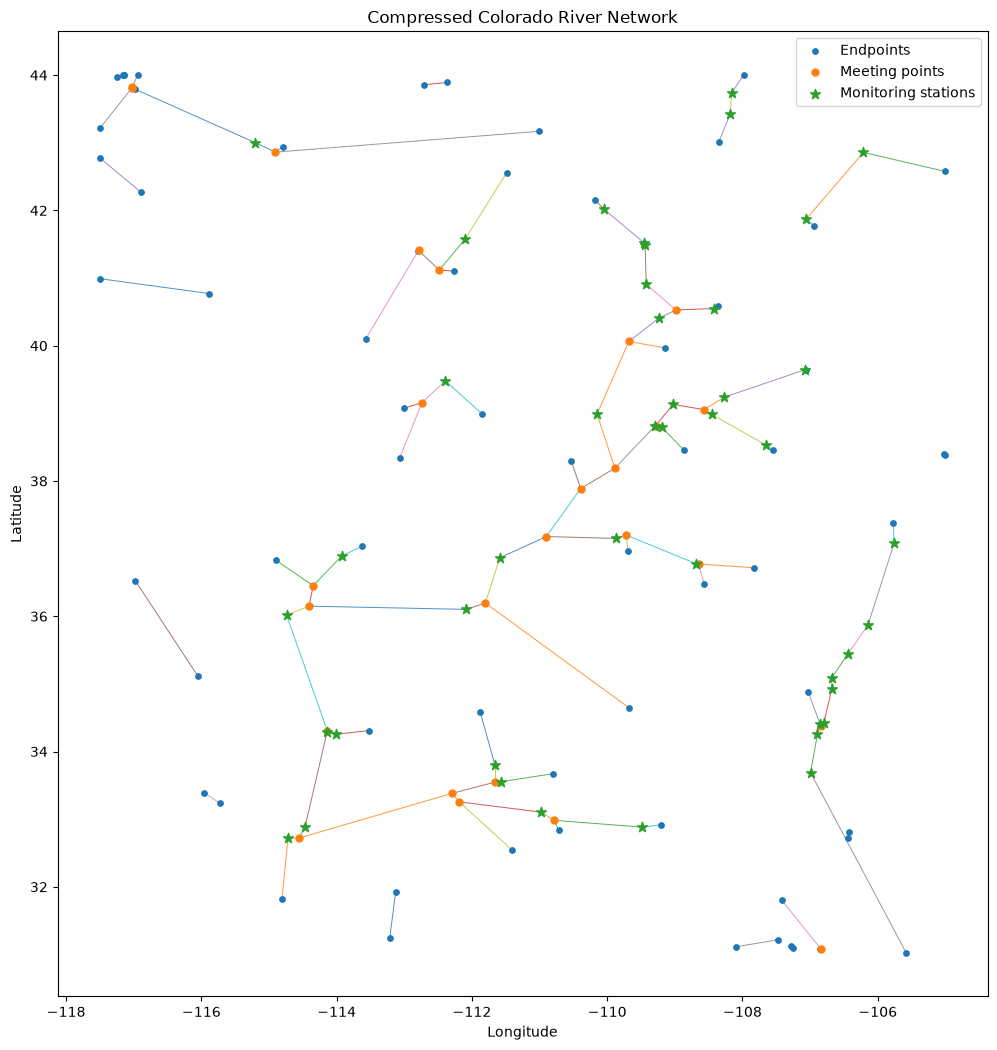

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 14))

# -------------------------
# Draw compressed edges
# -------------------------

for u, v in G_compressed.edges():

    x1, y1 = pos[u]
    x2, y2 = pos[v]

    ax.plot(
        [x1, x2],
        [y1, y2],
        linewidth=0.7,
        alpha=0.8,
        zorder=1
    )


# -------------------------
# Endpoints
# -------------------------

endpoint_x = [
    pos[n][0]
    for n in endpoint_nodes
]

endpoint_y = [
    pos[n][1]
    for n in endpoint_nodes
]

ax.scatter(
    endpoint_x,
    endpoint_y,
    s=15,
    label="Endpoints",
    zorder=2
)


# -------------------------
# Meeting points
# -------------------------

meeting_x = [
    pos[n][0]
    for n in meeting_nodes
]

meeting_y = [
    pos[n][1]
    for n in meeting_nodes
]

ax.scatter(
    meeting_x,
    meeting_y,
    s=25,
    label="Meeting points",
    zorder=3
)


# -------------------------
# Monitoring stations
# -------------------------

station_x = [
    pos[n][0]
    for n in station_nodes
]

station_y = [
    pos[n][1]
    for n in station_nodes
]

ax.scatter(
    station_x,
    station_y,
    s=55,
    marker="*",
    label="Monitoring stations",
    zorder=4
)


ax.set_title(
    "Compressed Colorado River Network"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()

ax.set_aspect("equal", adjustable="box")

plt.show()

In [ ]:
print(
    "Original weak components:",
    nx.number_weakly_connected_components(G_stations)
)

print(
    "Compressed weak components:",
    nx.number_weakly_connected_components(G_compressed)
)

Original weak components: 21
Compressed weak components: 21


In [ ]:
largest_nodes = max(
    nx.weakly_connected_components(G_stations),
    key=len
)

G_largest = G_stations.subgraph(
    largest_nodes
).copy()

In [ ]:
print("Nodes:", G_largest.number_of_nodes())
print("Edges:", G_largest.number_of_edges())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_largest)
)

Nodes: 67401
Edges: 67400
Weak components: 1


In [ ]:
stations_in_largest = sum(
    data.get("station_count", 0)
    for _, data in G_largest.nodes(data=True)
)

print("Stations in largest component:", stations_in_largest)

Stations in largest component: 29


In [ ]:
G_compressed = compress_river_graph(G_largest)

print("Compressed nodes:", G_compressed.number_of_nodes())
print("Compressed edges:", G_compressed.number_of_edges())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_compressed)
)

Original nodes: 67401
Nodes that will remain: 66
Nodes eligible for compression: 67335
Compressed nodes: 66
Compressed edges: 65
Weak components: 1


In [ ]:
station_count = sum(
    data.get("station_count", 0)
    for _, data in G_compressed.nodes(data=True)
)

station_nodes = [
    n for n, data in G_compressed.nodes(data=True)
    if data.get("station_count", 0) > 0
]

print("Monitoring stations:", station_count)
print("Nodes containing stations:", len(station_nodes))

Monitoring stations: 29
Nodes containing stations: 28


In [ ]:
print("Endpoints:",
      sum(
          1 for n in G_compressed
          if G_compressed.in_degree(n) + G_compressed.out_degree(n) == 1
      ))

print("Degree-3 nodes:",
      sum(
          1 for n in G_compressed
          if G_compressed.in_degree(n) + G_compressed.out_degree(n) == 3
      ))

Endpoints: 20
Degree-3 nodes: 18


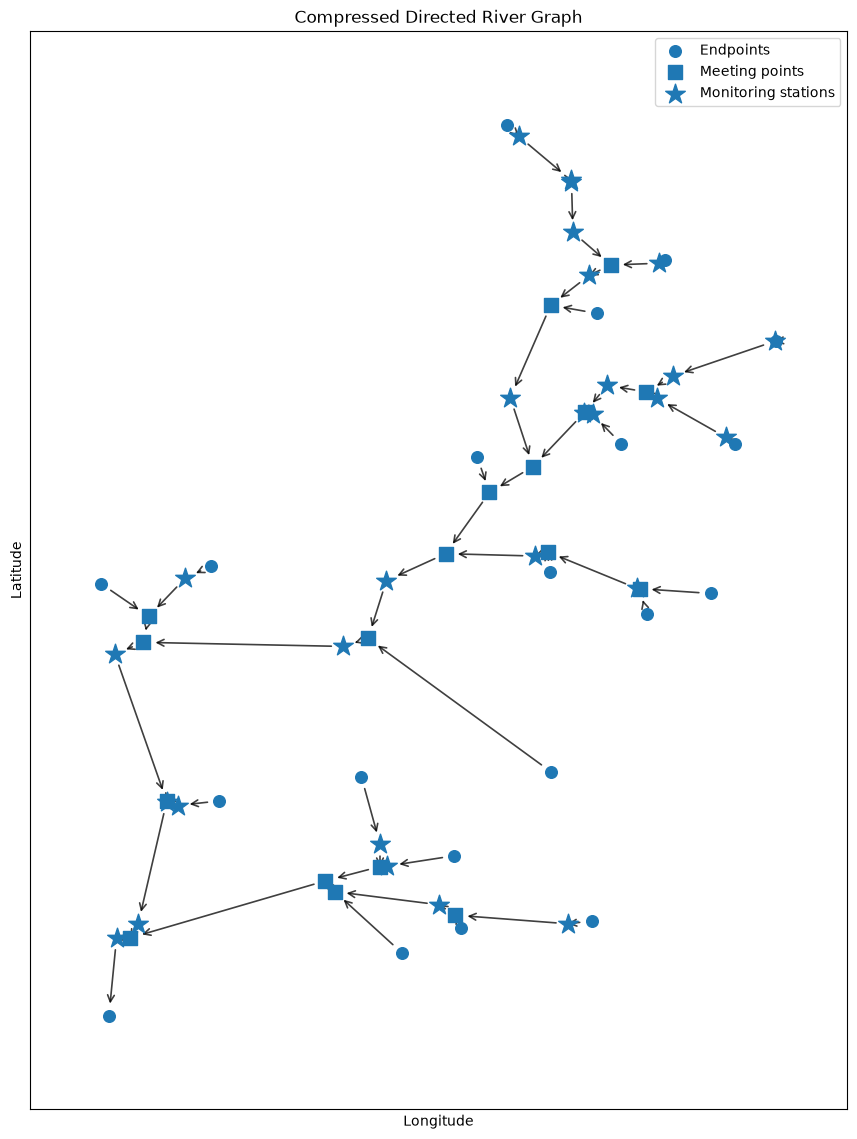

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Geographic positions from node attributes
pos = {
    node: (data["longitude"], data["latitude"])
    for node, data in G_compressed.nodes(data=True)
}

# Monitoring station nodes
station_nodes = [
    n for n, data in G_compressed.nodes(data=True)
    if data.get("station_count", 0) > 0
]

# Endpoints in compressed graph
endpoint_nodes = [
    n for n in G_compressed.nodes()
    if G_compressed.in_degree(n) + G_compressed.out_degree(n) == 1
]

# Meeting points in compressed graph
meeting_nodes = [
    n for n in G_compressed.nodes()
    if G_compressed.in_degree(n) + G_compressed.out_degree(n) >= 3
]

# Other nodes
other_nodes = [
    n for n in G_compressed.nodes()
    if n not in station_nodes
    and n not in endpoint_nodes
    and n not in meeting_nodes
]

fig, ax = plt.subplots(figsize=(12, 14))

# Draw directed edges with arrows
nx.draw_networkx_edges(
    G_compressed,
    pos,
    ax=ax,
    arrows=True,
    arrowstyle="->",
    arrowsize=12,
    width=1.2,
    alpha=0.75,
    min_source_margin=5,
    min_target_margin=5
)

# Draw other nodes
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=other_nodes,
    node_size=35,
    ax=ax,
    label="Other nodes"
)

# Draw endpoints
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=endpoint_nodes,
    node_size=70,
    ax=ax,
    label="Endpoints"
)

# Draw meeting points
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=meeting_nodes,
    node_size=110,
    node_shape="s",
    ax=ax,
    label="Meeting points"
)

# Draw station nodes
nx.draw_networkx_nodes(
    G_compressed,
    pos,
    nodelist=station_nodes,
    node_size=220,
    node_shape="*",
    ax=ax,
    label="Monitoring stations"
)

# Draw Station labels
# station_labels = {}

# for n in station_nodes:
#     stations = G_compressed.nodes[n].get("stations", [])
#     if len(stations) > 0:
#         station_labels[n] = stations[0]["station_id"]

# nx.draw_networkx_labels(
#     G_compressed,
#     pos,
#     labels=station_labels,
#     font_size=7,
#     ax=ax
# )

ax.set_title("Compressed Directed River Graph")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.show()

In [ ]:
print("Other nodes:", len(other_nodes))

for n in other_nodes:
    print(
        "Node:", n,
        "| in-degree:", G_compressed.in_degree(n),
        "| out-degree:", G_compressed.out_degree(n),
        "| total degree:",
        G_compressed.in_degree(n) + G_compressed.out_degree(n)
    )

Other nodes: 0


In [ ]:
import pickle

with open("compressed_river_graph.pkl", "wb") as f:
    pickle.dump(G_compressed, f)

print("Compressed graph saved.")


NameError: name 'G_compressed' is not defined

In [ ]:
with open("compressed_river_graph.pkl", "rb") as f:
    G_test = pickle.load(f)

print("Nodes:", G_test.number_of_nodes())
print("Edges:", G_test.number_of_edges())
print("Directed:", G_test.is_directed())
print(
    "Weak components:",
    nx.number_weakly_connected_components(G_test)
)

print(
    "Stations:",
    sum(
        data.get("station_count", 0)
        for _, data in G_test.nodes(data=True)
    )
)

Nodes: 66
Edges: 65
Directed: True
Weak components: 1
Stations: 29


In [ ]:
import pandas as pd

results = pd.read_csv(
    "river_water_quality_measurements.csv",
    low_memory=False
)

print("Rows:", len(results))
print("Stations:", results["Location_Identifier"].nunique())



Rows: 42544
Stations: 40


In [ ]:
STATION_COL = "Location_Identifier"
CHAR_COL = "Result_Characteristic"

station_coverage = (
    results
    .groupby(CHAR_COL)[STATION_COL]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="stations_with_data")
)

station_coverage.head(30)

,Result_Characteristic,stations_with_data
0,Total dissolved solids,38
1,Specific conductance,38
2,"Stream flow, instantaneous",38
3,"Hardness, Ca, Mg",37
4,pH,36
5,Calcium,34
6,Magnesium,34
7,Sulfate,33
8,Silica,33
9,Chloride,33


In [ ]:
import os

for file in os.listdir("."):
    if any(
        file.lower().endswith(ext)
        for ext in [".pkl", ".pickle", ".graphml", ".gml", ".gpickle"]
    ):
        print(file, os.path.getsize(file), "bytes")

largest_river_network.graphml 5271923 bytes
compressed_river_graph.pkl 0 bytes
river_graph_with_stations.pkl 10206273 bytes


In [ ]:
for name in [
    "G",
    "G_stations",
    "G_largest",
    "G_compressed"
]:
    print(name, "->", name in globals())

G -> False
G_stations -> False
G_largest -> False
G_compressed -> False


# Im not sure why but the saved data for the compressed graph is empty

In [18]:
import pickle
import networkx as nx

with open("river_graph_with_stations.pkl", "rb") as f:
    G_stations = pickle.load(f)

print("Nodes:", G_stations.number_of_nodes())
print("Edges:", G_stations.number_of_edges())
print("Directed:", G_stations.is_directed())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_stations)
)

print(
    "Stations:",
    sum(
        data.get("station_count", 0)
        for _, data in G_stations.nodes(data=True)
    )
)

Nodes: 124374
Edges: 124353
Directed: True
Weak components: 21
Stations: 45


In [19]:
largest_nodes = max(
    nx.weakly_connected_components(G_stations),
    key=len
)

G_largest = G_stations.subgraph(
    largest_nodes
).copy()

print("Largest component nodes:", G_largest.number_of_nodes())
print("Largest component edges:", G_largest.number_of_edges())

print(
    "Weak components:",
    nx.number_weakly_connected_components(G_largest)
)

print(
    "Stations in largest component:",
    sum(
        data.get("station_count", 0)
        for _, data in G_largest.nodes(data=True)
    )
)

Largest component nodes: 67401
Largest component edges: 67400
Weak components: 1
Stations in largest component: 29


In [20]:
def compress_river_graph(G):

    keep_nodes = set()

    # Keep stations and anything that is NOT a simple 1-in / 1-out node
    for node in G.nodes():

        data = G.nodes[node]

        has_station = data.get("station_count", 0) > 0

        straight_node = (
            G.in_degree(node) == 1
            and G.out_degree(node) == 1
        )

        if has_station or not straight_node:
            keep_nodes.add(node)

    print("Original nodes:", G.number_of_nodes())
    print("Nodes that will remain:", len(keep_nodes))
    print(
        "Nodes eligible for compression:",
        G.number_of_nodes() - len(keep_nodes)
    )

    C = nx.DiGraph()

    C.graph.update(G.graph)

    # Copy retained nodes and their metadata
    for node in keep_nodes:
        C.add_node(
            node,
            **G.nodes[node]
        )

    # Geographic distance
    def distance_m(node1, node2):

        d1 = G.nodes[node1]
        d2 = G.nodes[node2]

        lat1 = math.radians(d1["latitude"])
        lon1 = math.radians(d1["longitude"])

        lat2 = math.radians(d2["latitude"])
        lon2 = math.radians(d2["longitude"])

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = (
            math.sin(dlat / 2) ** 2
            +
            math.cos(lat1)
            * math.cos(lat2)
            * math.sin(dlon / 2) ** 2
        )

        c = 2 * math.atan2(
            math.sqrt(a),
            math.sqrt(1 - a)
        )

        return 6371000 * c

    # Compress every chain
    for start in keep_nodes:

        for first_next in G.successors(start):

            path = [start, first_next]
            current = first_next

            while current not in keep_nodes:

                successors = list(
                    G.successors(current)
                )

                if len(successors) != 1:
                    break

                next_node = successors[0]

                if next_node in path:
                    break

                path.append(next_node)
                current = next_node

            end = path[-1]

            if end not in keep_nodes:
                continue

            total_length_m = sum(
                distance_m(u, v)
                for u, v in zip(
                    path[:-1],
                    path[1:]
                )
            )

            C.add_edge(
                start,
                end,
                weight=total_length_m,
                length_m=total_length_m,
                original_edge_count=len(path) - 1,
                compressed_node_count=max(0, len(path) - 2),
                original_path=path
            )

    return C

In [22]:
import math

G_compressed = compress_river_graph(
    G_largest
)

print("\nCOMPRESSED GRAPH")
print("----------------")

print(
    "Nodes:",
    G_compressed.number_of_nodes()
)

print(
    "Edges:",
    G_compressed.number_of_edges()
)

print(
    "Directed:",
    G_compressed.is_directed()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_compressed
    )
)

print(
    "Stations:",
    sum(
        data.get("station_count", 0)
        for _, data in G_compressed.nodes(data=True)
    )
)

Original nodes: 67401
Nodes that will remain: 66
Nodes eligible for compression: 67335

COMPRESSED GRAPH
----------------
Nodes: 66
Edges: 65
Directed: True
Weak components: 1
Stations: 29


In [23]:
import os

bad_file = "compressed_river_graph.pkl"

if os.path.exists(bad_file):
    os.remove(bad_file)

print("Old broken file removed.")

Old broken file removed.


In [24]:
temp_file = "compressed_river_graph.tmp"
final_file = "compressed_river_graph.pkl"

with open(temp_file, "wb") as f:
    pickle.dump(
        G_compressed,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

os.replace(
    temp_file,
    final_file
)

print(
    "Saved:",
    final_file
)

print(
    "File size:",
    os.path.getsize(final_file),
    "bytes"
)

Saved: compressed_river_graph.pkl
File size: 350634 bytes


In [25]:
with open(
    "compressed_river_graph.pkl",
    "rb"
) as f:

    G_test = pickle.load(f)


print("Reloaded successfully.")

print(
    "Nodes:",
    G_test.number_of_nodes()
)

print(
    "Edges:",
    G_test.number_of_edges()
)

print(
    "Weak components:",
    nx.number_weakly_connected_components(
        G_test
    )
)

print(
    "Stations:",
    sum(
        data.get("station_count", 0)
        for _, data in G_test.nodes(data=True)
    )
)

Reloaded successfully.
Nodes: 66
Edges: 65
Weak components: 1
Stations: 29


In [26]:
compressed_station_ids = []

for node, data in G_compressed.nodes(data=True):

    for station in data.get("stations", []):
        compressed_station_ids.append(
            str(station["station_id"])
        )

compressed_station_ids = set(compressed_station_ids)

print("Stations in compressed graph:", len(compressed_station_ids))

Stations in compressed graph: 29


In [27]:
results_largest = results[
    results["Location_Identifier"]
    .astype(str)
    .isin(compressed_station_ids)
].copy()

print(
    "Stations in original results:",
    results["Location_Identifier"].nunique()
)

print(
    "Stations in largest component:",
    results_largest["Location_Identifier"].nunique()
)

print(
    "Measurements in largest component:",
    len(results_largest)
)

Stations in original results: 40
Stations in largest component: 28
Measurements in largest component: 41338


In [30]:
STATION_COL = "Location_Identifier"
CHAR_COL = "Result_Characteristic"

total_stations = results_largest[STATION_COL].nunique()

station_summary = (
    results_largest
    .groupby(CHAR_COL)
    .agg(
        stations_with_data=(STATION_COL, "nunique"),
        total_measurements=(STATION_COL, "size")
    )
    .reset_index()
)

station_summary["coverage_percent"] = (
    station_summary["stations_with_data"]
    / total_stations
    * 100
).round(1)

station_summary = station_summary.sort_values(
    ["stations_with_data", "total_measurements"],
    ascending=False
).reset_index(drop=True)

station_summary.head(30)

,Result_Characteristic,stations_with_data,total_measurements,coverage_percent
0,Total dissolved solids,28,3038,100.0
1,Specific conductance,28,1490,100.0
2,"Hardness, Ca, Mg",27,909,96.4
3,pH,26,1192,92.9
4,"Stream flow, instantaneous",26,594,92.9
5,Magnesium,25,1028,89.3
6,Calcium,25,1011,89.3
7,"Hardness, non-carbonate",25,803,89.3
8,Sodium adsorption ratio [(Na)/(sq root of 1/2 ...,24,839,85.7
9,Carbon dioxide,24,795,85.7
